
Processing model: w2v

=== Mean squared correlations for this model ===
pred_vs_group: 0.0003
subj_vs_group: 0.0323
pred_vs_actual: 0.0052
pred_vs_other_story: 0.0055
pred_vs_other_story_group: 0.0004


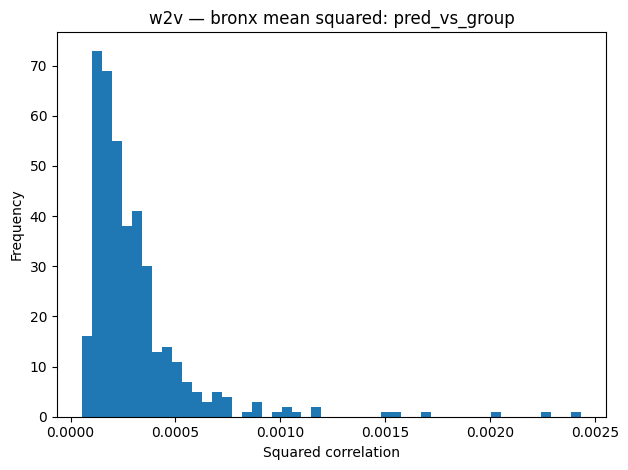

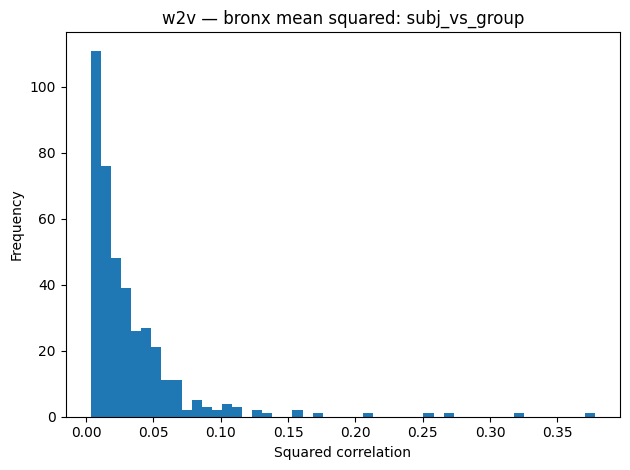

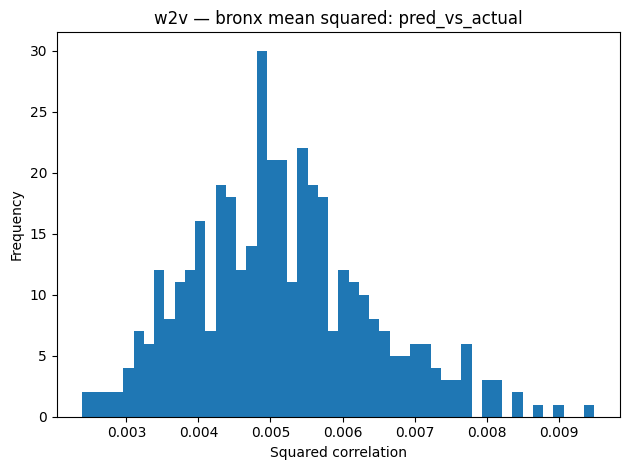

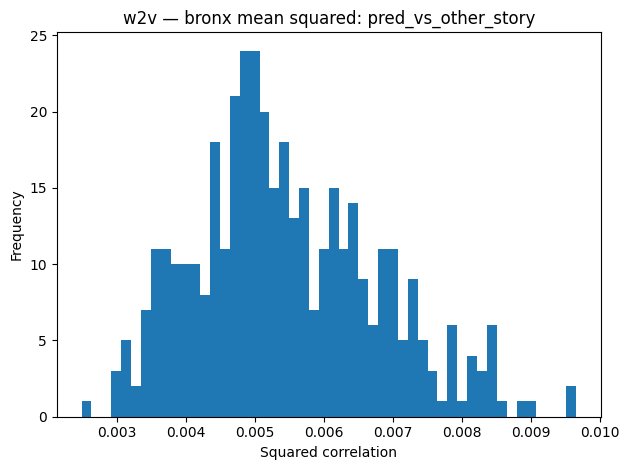

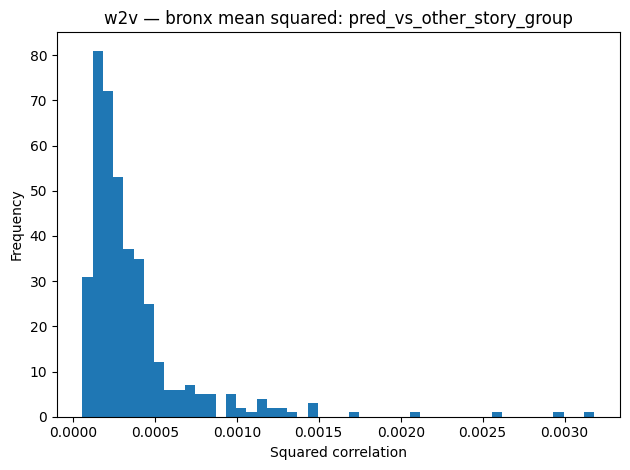


Processing model: llama

=== Mean squared correlations for this model ===
pred_vs_group: 0.0005
subj_vs_group: 0.0323
pred_vs_actual: 0.0056
pred_vs_other_story: 0.0060
pred_vs_other_story_group: 0.0006


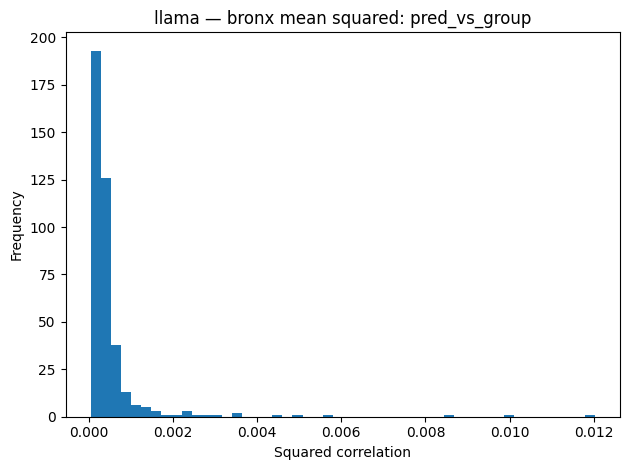

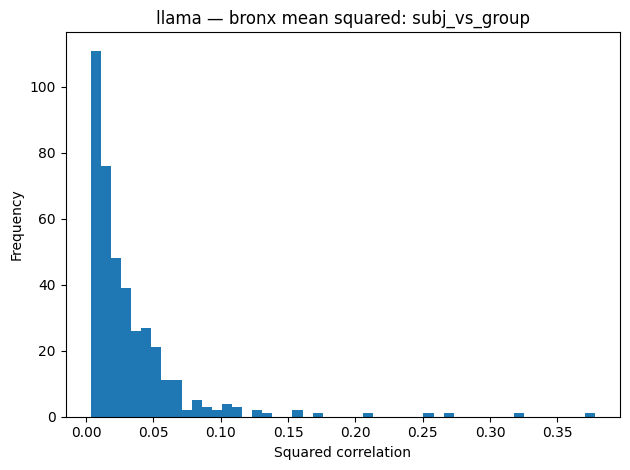

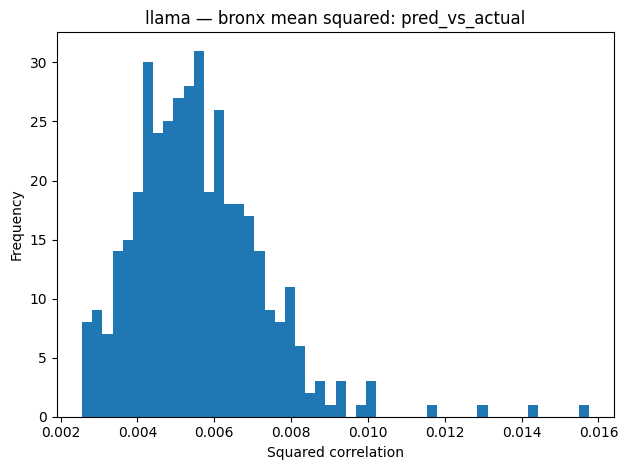

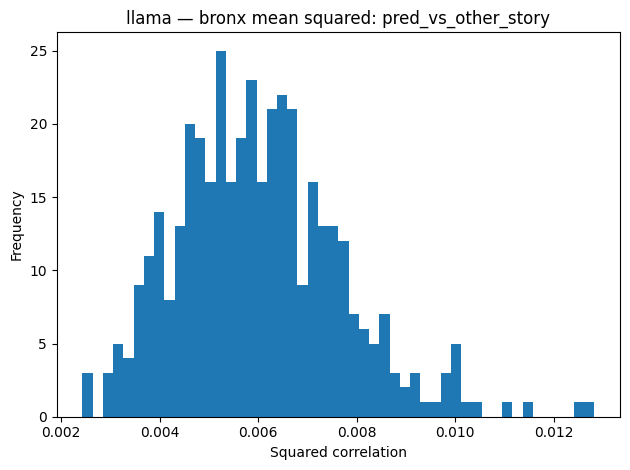

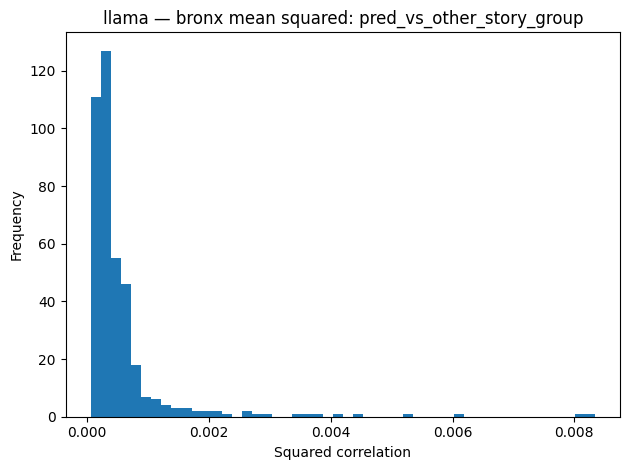


Processing model: llama3

=== Mean squared correlations for this model ===
pred_vs_group: 0.0006
subj_vs_group: 0.0323
pred_vs_actual: 0.0058
pred_vs_other_story: 0.0062
pred_vs_other_story_group: 0.0006


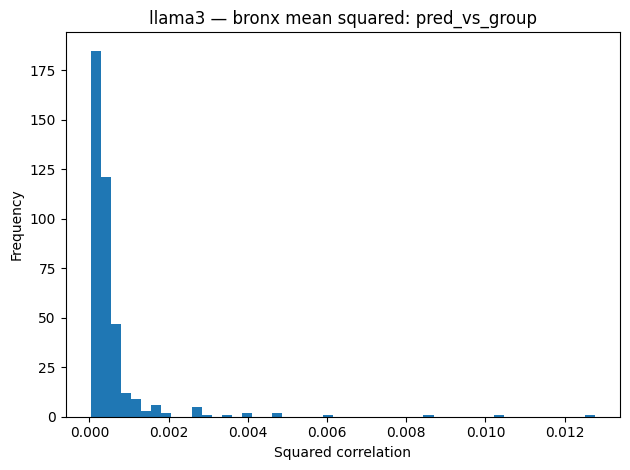

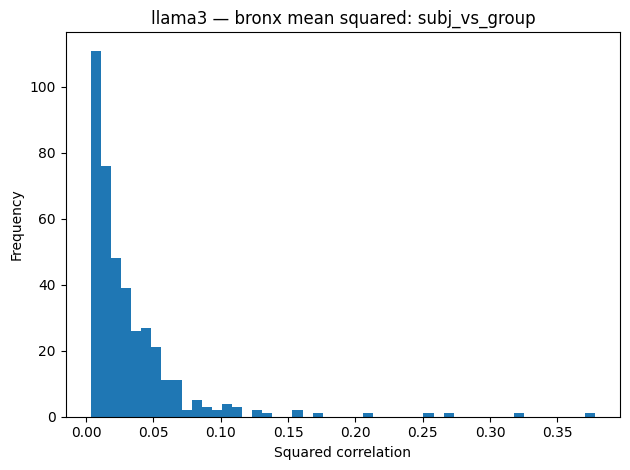

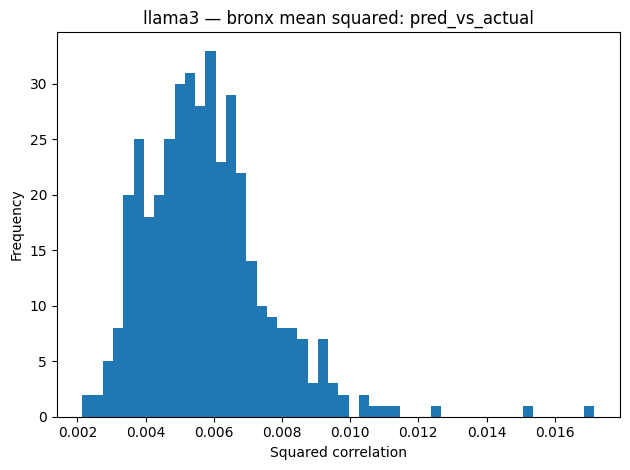

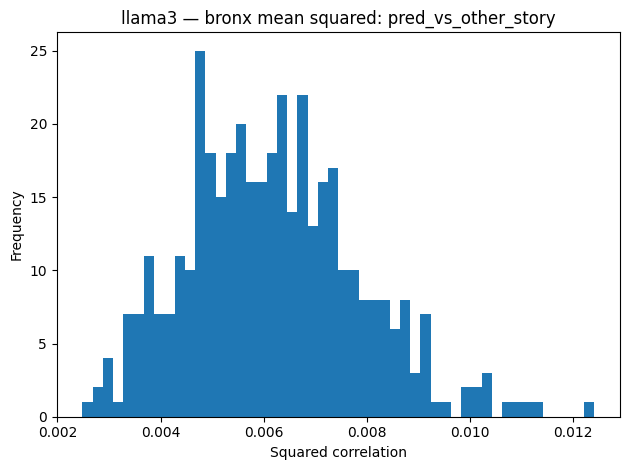

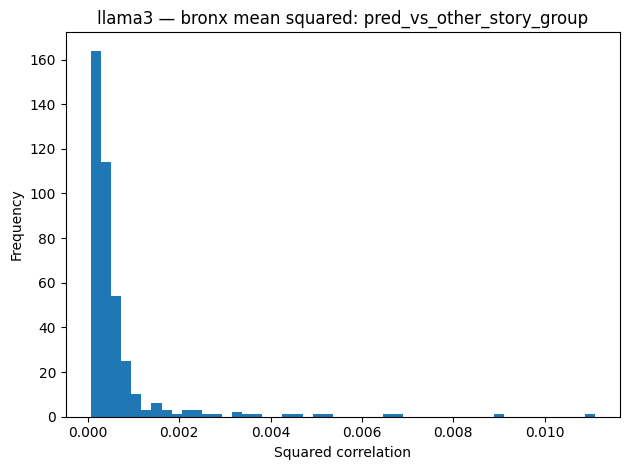


Processing model: gpt2

=== Mean squared correlations for this model ===
pred_vs_group: 0.0007
subj_vs_group: 0.0323
pred_vs_actual: 0.0063
pred_vs_other_story: 0.0068
pred_vs_other_story_group: 0.0009


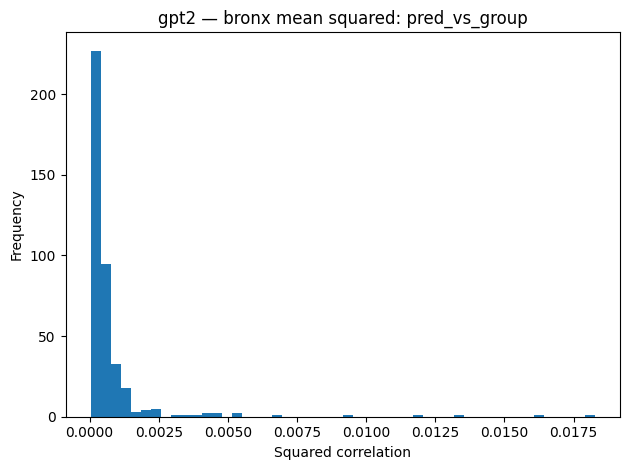

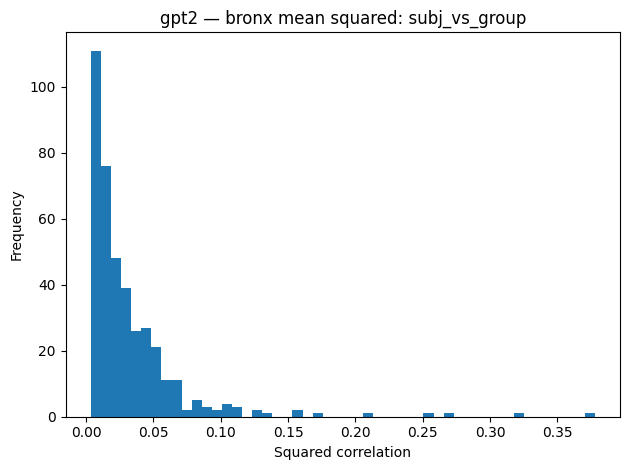

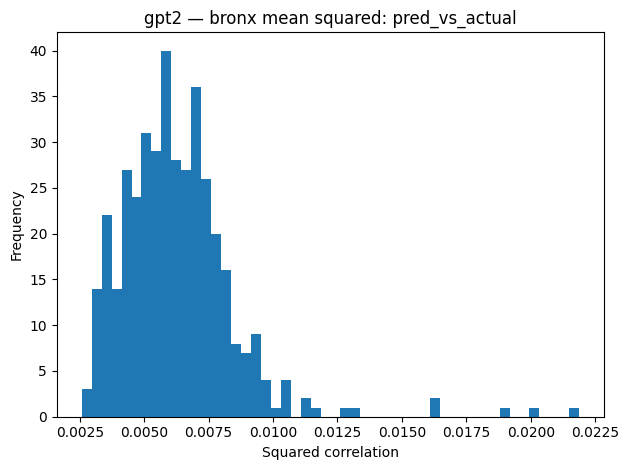

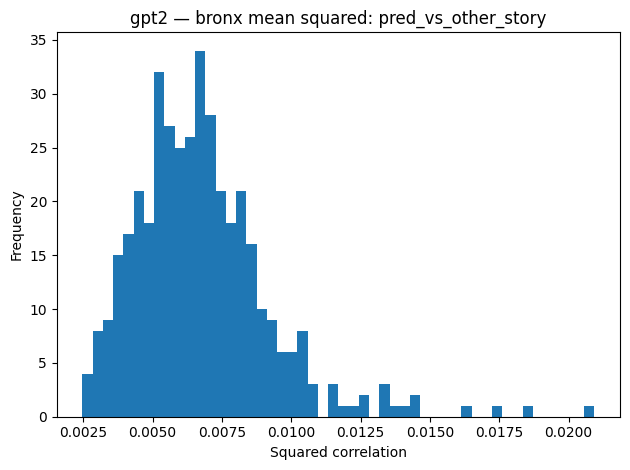

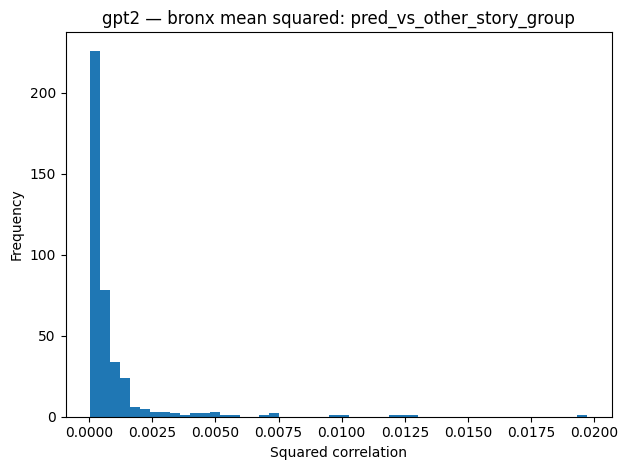


Processing model: gpt_oss

=== Mean squared correlations for this model ===
pred_vs_group: 0.0005
subj_vs_group: 0.0323
pred_vs_actual: 0.0056
pred_vs_other_story: 0.0058
pred_vs_other_story_group: 0.0006


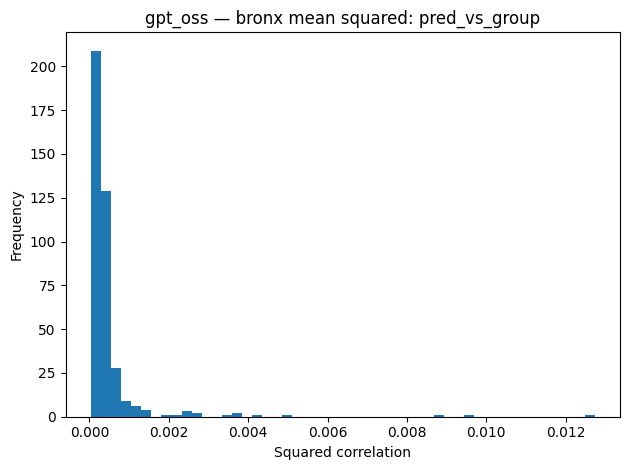

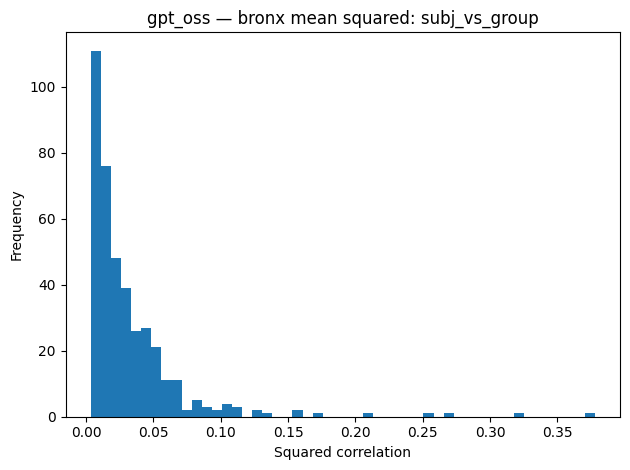

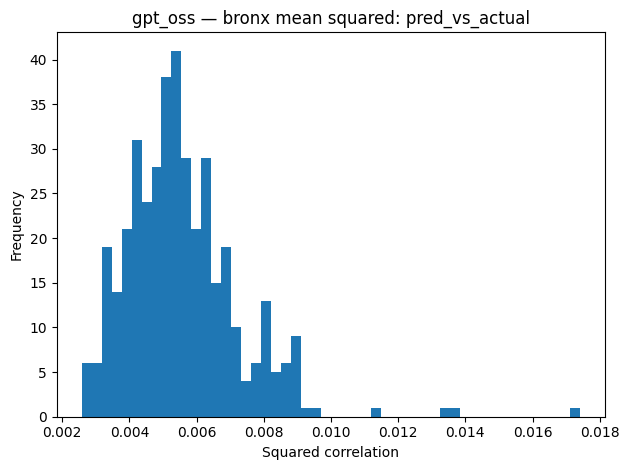

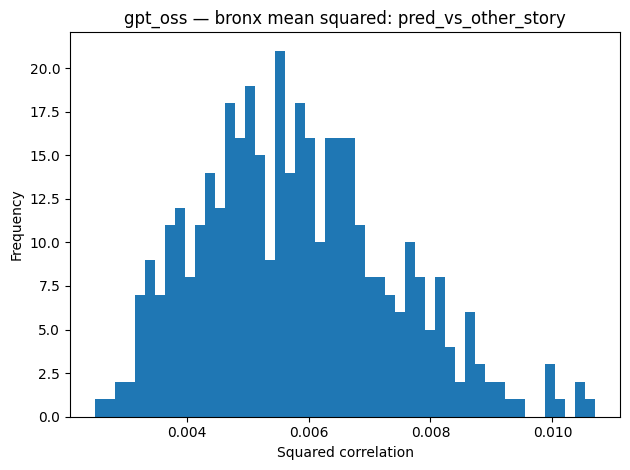

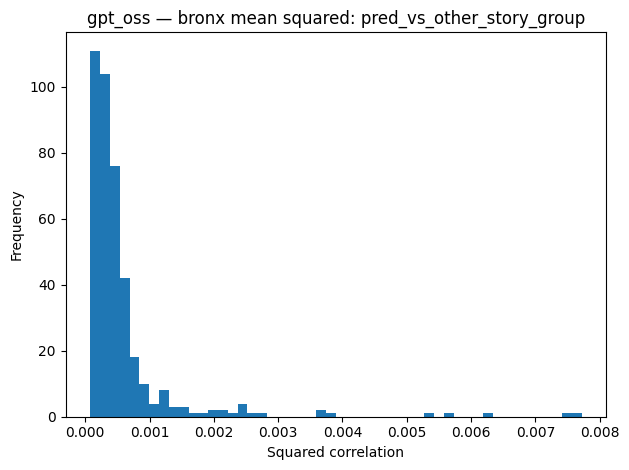


Processing model: gte

=== Mean squared correlations for this model ===
pred_vs_group: 0.0007
subj_vs_group: 0.0323
pred_vs_actual: 0.0063
pred_vs_other_story: 0.0070
pred_vs_other_story_group: 0.0010


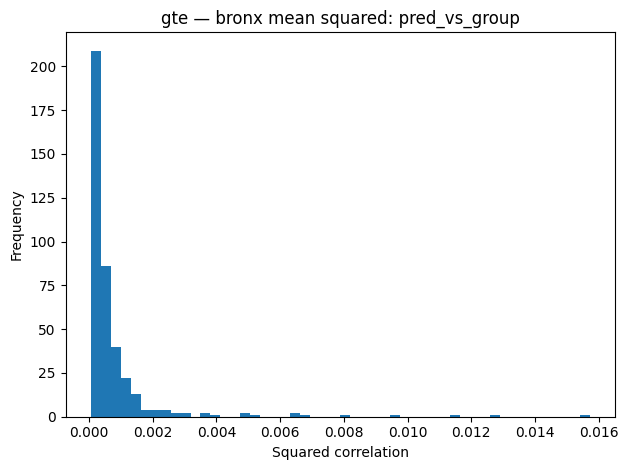

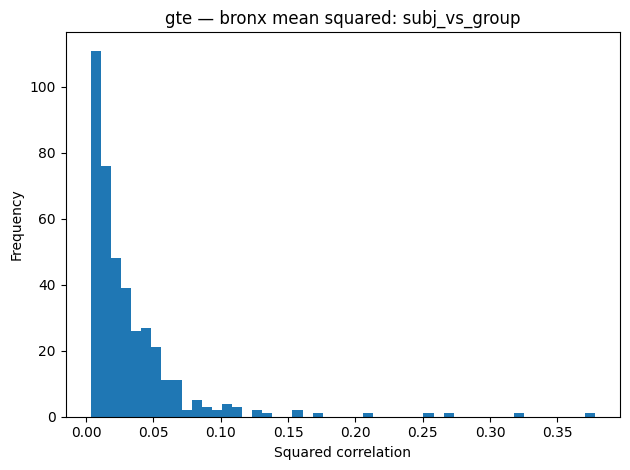

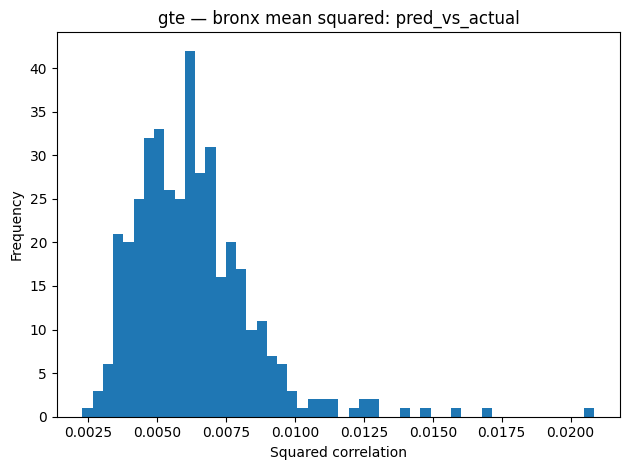

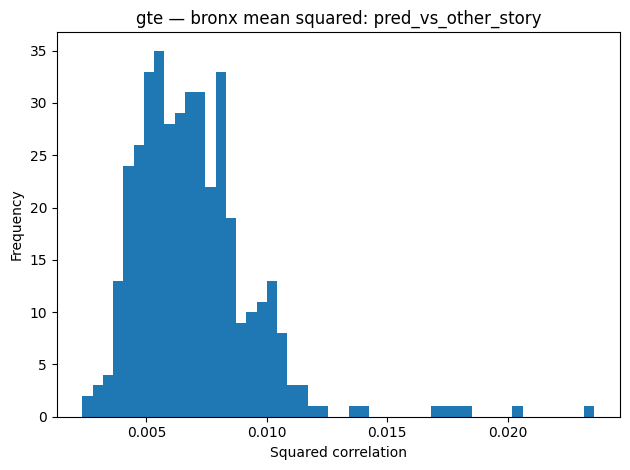

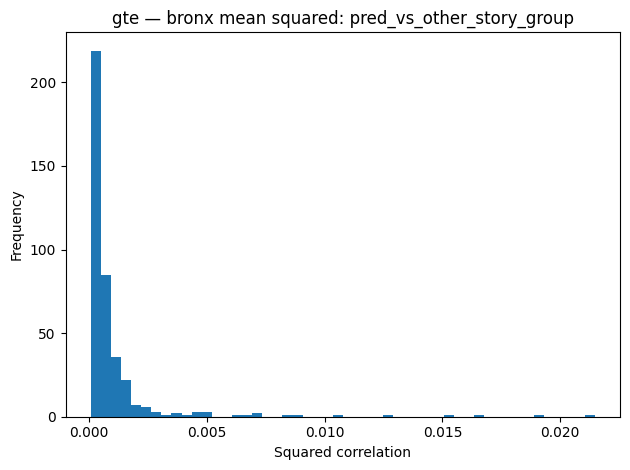


✔ ALL models summary saved: /home/y-sato/venv/kenkyu1/analysis_corr/bronx_ALLMODELS_mean_squared_clean_corr_summary.csv
     model  pred_vs_group  subj_vs_group  pred_vs_actual  pred_vs_other_story  \
0      w2v       0.000306       0.032271        0.005166             0.005456   
1    llama       0.000523       0.032271        0.005586             0.006029   
2   llama3       0.000563       0.032271        0.005782             0.006186   
3     gpt2       0.000743       0.032271        0.006271             0.006757   
4  gpt_oss       0.000489       0.032271        0.005561             0.005798   
5      gte       0.000750       0.032271        0.006298             0.006964   

   pred_vs_other_story_group  
0                   0.000366  
1                   0.000566  
2                   0.000615  
3                   0.000915  
4                   0.000566  
5                   0.001032  


In [ ]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt

# =====================================================
# 一括処理したいモデル一覧
# =====================================================
model_list = ["w2v", "llama", "llama3", "gpt2", "gpt_oss", "gte"]
train_story =  "bronx"
test_story = "piemanpni"

base_dir = "/home/y-sato/venv/kenkyu1/analysis_corr"

# =====================================================
# 結果をまとめるテーブル（後で CSV にする）
# =====================================================
summary_rows = []

# =====================================================
# モデルごとにループ処理
# =====================================================
for model_name in model_list:
    print("\n==========================================")
    print(f"Processing model: {model_name}")
    print("==========================================")

    input_file = f"{base_dir}/{model_name}_{train_story}_allsubjects_with_{test_story}_clean_corr_df.csv"

    # ----------------------
    # ② データ読み込み
    # ----------------------
    df = pd.read_csv(input_file)

    # ----------------------
    # ③ 二乗する相関の列
    # ----------------------
    corr_cols = [
        "pred_vs_group",
        "subj_vs_group",
        "pred_vs_actual",
        "pred_vs_other_story",
        "pred_vs_other_story_group"
    ]

    df_squared = df.copy()
    df_squared[corr_cols] = df_squared[corr_cols] ** 2

    # ----------------------
    # ④ Parcel ごとの平均保存
    # ----------------------
    df_parcel_mean = (
        df_squared.groupby("parcel")[corr_cols]
        .mean()
        .reset_index()
    )
    # parcel_out = f"{base_dir}/{model_name}_{train_story}_parcel_mean_squared_corr.csv"
    # df_parcel_mean.to_csv(parcel_out, index=False, encoding="utf-8-sig")
    # print("✔ Parcel average saved:", parcel_out)

    # ----------------------
    # ⑤ Subject ごとの平均保存
    # ----------------------
    df_subject_mean = (
        df_squared.groupby("subject")[corr_cols]
        .mean()
        .reset_index()
    )
    # subject_out = f"{base_dir}/{model_name}_{train_story}_subject_mean_squared_corr.csv"
    # df_subject_mean.to_csv(subject_out, index=False, encoding="utf-8-sig")
    # print("✔ Subject average saved:", subject_out)

    # ----------------------
    # ⑥ 24パターン一致率
    # ----------------------
    metric_cols = [
        "pred_vs_actual",
        "pred_vs_other_story",
        "pred_vs_group",
        "pred_vs_other_story_group",
    ]

    perms = itertools.permutations(metric_cols)
    pattern_names = []
    pattern_conditions = {}

    for perm in perms:
        name = " > ".join(perm)
        pattern_names.append(name)

        cond = True
        for i in range(len(perm) - 1):
            cond = cond & (df_squared[perm[i]] > df_squared[perm[i+1]])

        pattern_conditions[name] = cond

    df_squared["pattern_24"] = "none"
    for name in pattern_names:
        df_squared.loc[pattern_conditions[name], "pattern_24"] = name

    pattern_rate = df_squared["pattern_24"].value_counts(normalize=True)

    pattern_df = pattern_rate.reset_index()
    pattern_df.columns = ["pattern", "rate"]

    full_pattern_df = pd.DataFrame({"pattern": pattern_names})
    full_pattern_df = full_pattern_df.merge(pattern_df, on="pattern", how="left")
    full_pattern_df["rate"] = full_pattern_df["rate"].fillna(0)
    full_pattern_df = full_pattern_df.sort_values("rate", ascending=False)

    # pattern_out = f"{base_dir}/{model_name}_{train_story}_24pattern_results_squared.csv"
    # full_pattern_df.to_csv(pattern_out, index=False, encoding="utf-8-sig")
    # print("✔ 24-pattern CSV saved:", pattern_out)

    # ----------------------
    # ⑦ Mean squared correlations（ここを集計）
    # ----------------------
    print("\n=== Mean squared correlations for this model ===")
    row = {"model": model_name}

    for col in corr_cols:
        mean_val = df_squared[col].mean()
        row[col] = mean_val
        print(f"{col}: {mean_val:.4f}")

    summary_rows.append(row)

    # ----------------------
    # ⑧ Parcel平均のヒストグラム（任意）
    # ----------------------
    df_hist = df_parcel_mean.copy()
    exclude_cols = ["subject", "parcel", "network"]
    plot_cols = [c for c in df_hist.columns if c not in exclude_cols]

    for col in plot_cols:
        plt.figure()
        plt.hist(df_hist[col].dropna(), bins=50)
        plt.title(f"{model_name} — {train_story} mean squared: {col}")
        plt.xlabel("Squared correlation")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()


# =====================================================
# ★ 最後に全モデルまとめた CSV を出力 ★
# =====================================================
df_summary = pd.DataFrame(summary_rows)
summary_csv = f"{base_dir}/{train_story}_ALLMODELS_mean_squared_clean_corr_summary.csv"
df_summary.to_csv(summary_csv, index=False, encoding="utf-8-sig")

print("\n==========================================")
print("✔ ALL models summary saved:", summary_csv)
print(df_summary)
print("==========================================")


/tmp/ipykernel_1044176/4076723978.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.replace("_", "\n") for m in corr_cols])


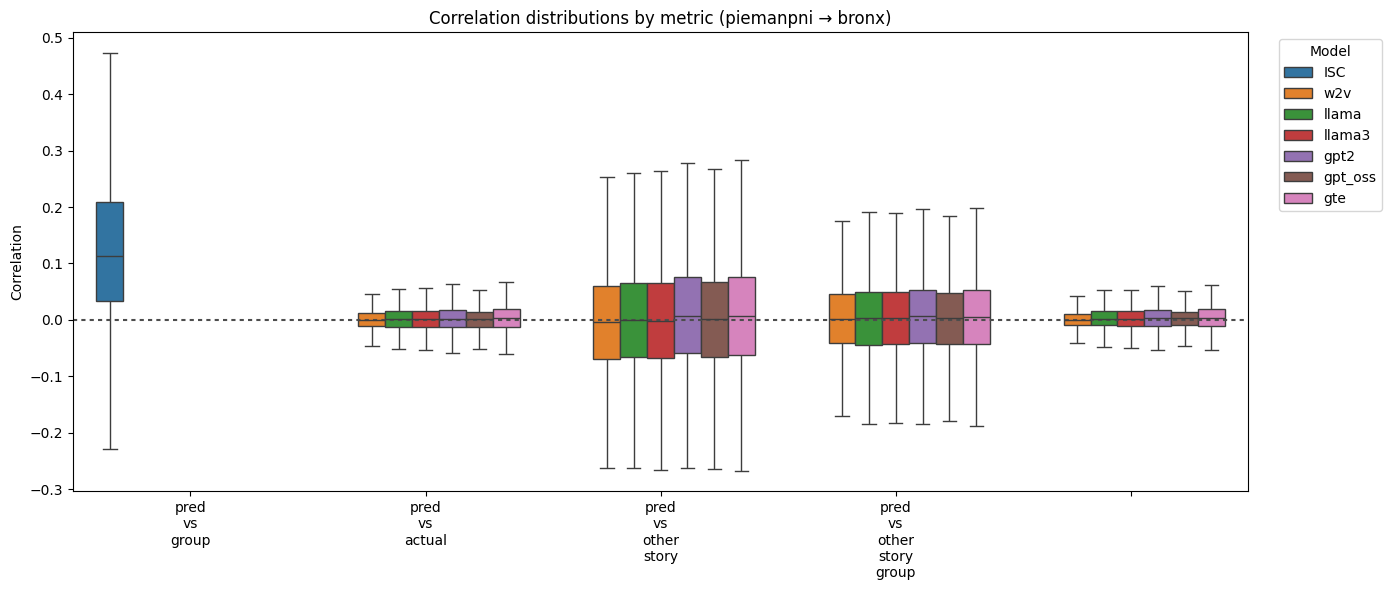

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_list = ["w2v", "llama", "llama3", "gpt2", "gpt_oss", "gte"]
train_story = "piemanpni"
test_story  = "bronx"

base_dir = "/home/y-sato/venv/kenkyu1/analysis_corr"

corr_cols = [
    "pred_vs_group",
    "pred_vs_actual",
    "pred_vs_other_story",
    "pred_vs_other_story_group"
]

isc_col = "subj_vs_group"

# =====================================================
# データまとめ
# =====================================================
all_rows = []

# ===== ISC（1回だけ）=====
df_isc = pd.read_csv(
    f"{base_dir}/{model_list[0]}_{train_story}_allsubjects_with_{test_story}_clean_corr_df.csv"
)

isc_rows = pd.DataFrame({
    "model": "ISC",
    "metric": "ISC",
    "correlation": df_isc[isc_col].dropna()
})

all_rows.append(isc_rows)

# ===== 各モデル × 各指標 =====
for model_name in model_list:
    df = pd.read_csv(
        f"{base_dir}/{model_name}_{train_story}_allsubjects_with_{test_story}_clean_corr_df.csv"
    )

    for col in corr_cols:
        tmp = pd.DataFrame({
            "model": model_name,
            "metric": col,
            "correlation": df[col].dropna()
        })
        all_rows.append(tmp)

plot_df = pd.concat(all_rows, ignore_index=True)

# =====================================================
# 描画
# =====================================================
plt.figure(figsize=(14, 6))

ax = sns.boxplot(
    data=plot_df,
    x="metric",
    y="correlation",
    hue="model",           # ★ モデルごとに色分け
    showfliers=False
)

ax.axhline(0, color=".3", dashes=(2, 2))

ax.set_xlabel("")
ax.set_ylabel("Correlation")
ax.set_title(f"Correlation distributions by metric ({train_story} → {test_story})")

# x軸ラベルを見やすく
ax.set_xticklabels([m.replace("_", "\n") for m in corr_cols])

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1044176/533498704.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.replace("_", "\n") for m in metric_order])


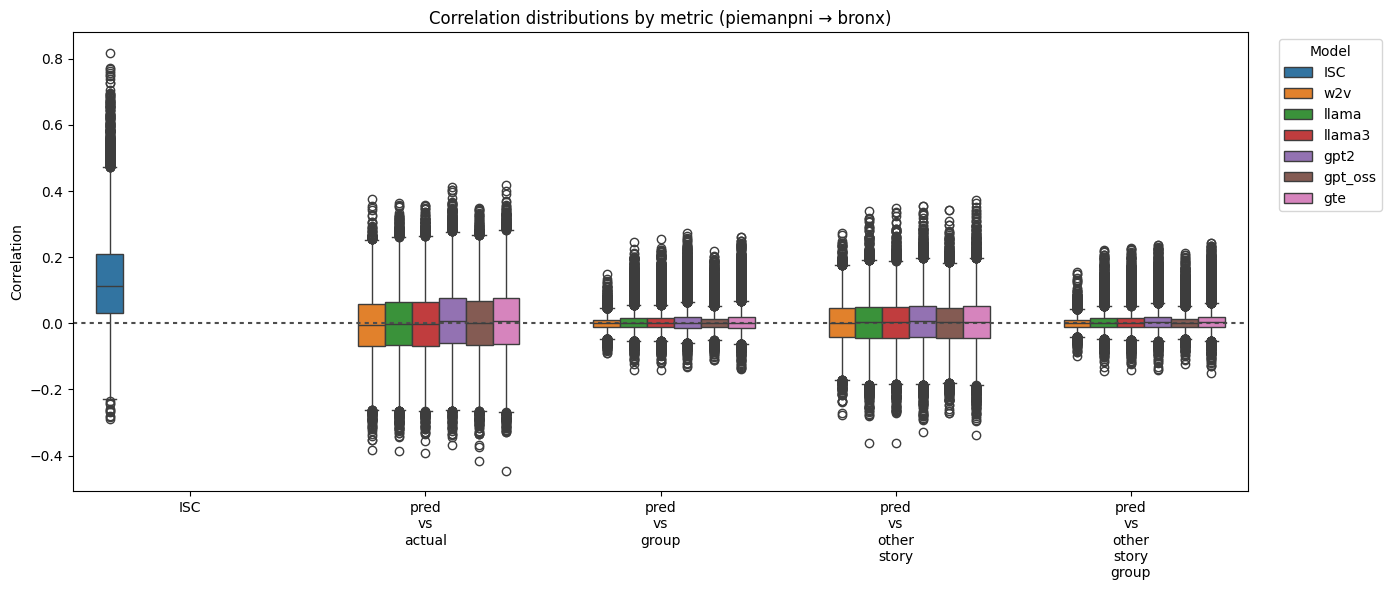

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_list = ["w2v", "llama", "llama3", "gpt2", "gpt_oss", "gte"]
train_story = "piemanpni"
test_story  = "bronx"

base_dir = "/home/y-sato/venv/kenkyu1/analysis_corr"

corr_cols = [
    "pred_vs_group",
    "pred_vs_actual",
    "pred_vs_other_story",
    "pred_vs_other_story_group"
]

isc_col = "subj_vs_group"

# =====================================================
# データまとめ
# =====================================================
all_rows = []

# ===== ISC（1回だけ）=====
df_isc = pd.read_csv(
    f"{base_dir}/{model_list[0]}_{train_story}_allsubjects_with_{test_story}_clean_corr_df.csv"
)

isc_rows = pd.DataFrame({
    "model": "ISC",
    "metric": "ISC",
    "correlation": df_isc[isc_col].dropna()
})

all_rows.append(isc_rows)

# ===== 各モデル × 各指標 =====
for model_name in model_list:
    df = pd.read_csv(
        f"{base_dir}/{model_name}_{train_story}_allsubjects_with_{test_story}_clean_corr_df.csv"
    )

    for col in corr_cols:
        tmp = pd.DataFrame({
            "model": model_name,
            "metric": col,
            "correlation": df[col].dropna()
        })
        all_rows.append(tmp)

plot_df = pd.concat(all_rows, ignore_index=True)
# =====================================================
# metric の順番を明示（ISC + pred_vs_actual を最初に）
# =====================================================
metric_order = [
    "ISC",
    "pred_vs_actual",
    "pred_vs_group",
    "pred_vs_other_story",
    "pred_vs_other_story_group"
]

plot_df["metric"] = pd.Categorical(
    plot_df["metric"],
    categories=metric_order,
    ordered=True
)

# =====================================================
# 描画
# =====================================================
plt.figure(figsize=(14, 6))

ax = sns.boxplot(
    data=plot_df,
    x="metric",
    y="correlation",
    hue="model",
    order=metric_order,
    # showfliers=True,     # ★ 丸を表示
    dodge=True
)

ax.axhline(0, color=".3", dashes=(2, 2))

ax.set_xlabel("")
ax.set_ylabel("Correlation")
ax.set_title(f"Correlation distributions by metric ({train_story} → {test_story})")

# x軸ラベルを見やすく
ax.set_xticklabels([m.replace("_", "\n") for m in metric_order])

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1044176/1920655134.py:105: UserWarning: The palette list has more values (7) than needed (6), which may not be intended.
  ax = sns.boxplot(
/tmp/ipykernel_1044176/1920655134.py:117: UserWarning: The palette list has more values (7) than needed (1), which may not be intended.
  sns.boxplot(
/tmp/ipykernel_1044176/1920655134.py:143: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([metric_label_map[m] for m in metric_order], rotation=15, ha='right')
/tmp/ipykernel_1044176/1920655134.py:150: UserWarning: Glyph 12288 (\N{IDEOGRAPHIC SPACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1044176/1920655134.py:151: UserWarning: Glyph 12288 (\N{IDEOGRAPHIC SPACE}) missing from font(s) DejaVu Sans.
  plt.savefig(out_path, dpi=300, bbox_inches="tight")
/home/y-sato/.venv/sotu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 122

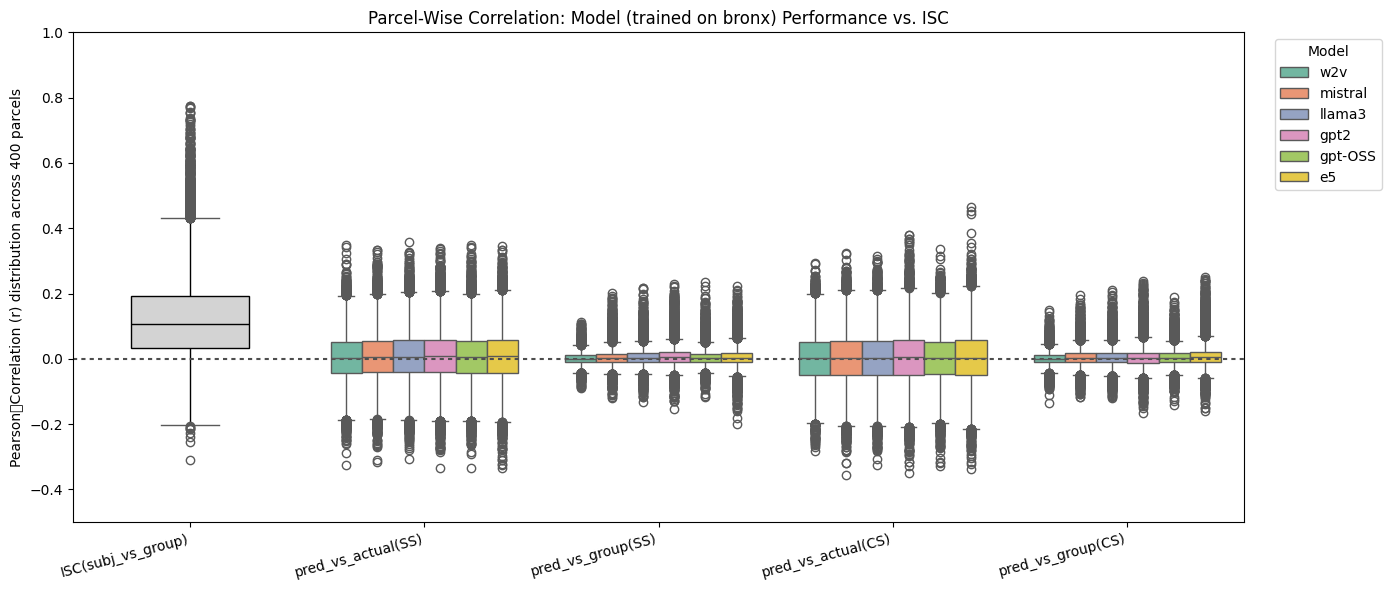

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_list = ["w2v", "llama", "llama3", "gpt2", "gpt_oss", "gte"]
train_story = "bronx"
test_story  = "piemanpni"

base_dir = "/home/y-sato/venv/kenkyu1/analysis_corr"
out_path = (
    f"{base_dir}/boxplot_corr_{train_story}_to_{test_story}_hako.png"
)
corr_cols = [
    "pred_vs_group",
    "pred_vs_actual",
    "pred_vs_other_story",
    "pred_vs_other_story_group"
]

isc_col = "subj_vs_group"

# =====================================================
# データまとめ
# =====================================================
all_rows = []

# ===== ISC =====
df_isc = pd.read_csv(
    f"{base_dir}/{model_list[0]}_{train_story}_allsubjects_with_{test_story}_clean_corr_df.csv"
)

isc_rows = pd.DataFrame({
    "model": "ISC",
    "metric": "ISC",
    "correlation": df_isc[isc_col].dropna()
})
all_rows.append(isc_rows)

# ===== 各モデル × 各指標 =====
for model_name in model_list:
    df = pd.read_csv(
        f"{base_dir}/{model_name}_{train_story}_allsubjects_with_{test_story}_clean_corr_df.csv"
    )

    for col in corr_cols:
        tmp = pd.DataFrame({
            "model": model_name,
            "metric": col,
            "correlation": df[col].dropna()
        })
        all_rows.append(tmp)

plot_df = pd.concat(all_rows, ignore_index=True)

# =====================================================
# metric の順番
# =====================================================
metric_order = [
    "ISC",
    "pred_vs_actual",
    "pred_vs_group",
    "pred_vs_other_story",
    "pred_vs_other_story_group"
]

plot_df["metric"] = pd.Categorical(
    plot_df["metric"],
    categories=metric_order,
    ordered=True
)

metric_label_map = {
    "ISC": "ISC(subj_vs_group)",
    "pred_vs_actual": "pred_vs_actual(SS)",
    "pred_vs_group": "pred_vs_group(SS)",
    "pred_vs_other_story": "pred_vs_actual(CS)",
    "pred_vs_other_story_group": "pred_vs_group(CS)"
}

model_label_map = {
    "ISC": "ISC",
    "w2v": "w2v",
    "llama": "mistral",
    "llama3": "llama3",
    "gpt2": "gpt2",
    "gpt_oss": "gpt-OSS",
    "gte": "e5"
}
plot_df["model_label"] = plot_df["model"].map(model_label_map)
# =====================================================
# ISC とそれ以外を分離
# =====================================================
df_isc = plot_df[plot_df["model"] == "ISC"]
df_model = plot_df[plot_df["model"] != "ISC"]

# =====================================================
# 描画
# =====================================================
plt.figure(figsize=(14, 6))
# palette = sns.color_palette("viridis", n_colors=len(model_list) + 1)
# palette = sns.color_palette("viridis", n_colors=len(model_list) + 1)
palette = sns.color_palette("Set2", n_colors=len(model_list) + 1)

# --- 通常モデル ---
ax = sns.boxplot(
    data=df_model,
    x="metric",
    y="correlation",
    # hue="model",
    hue="model_label", 
    order=metric_order,
    dodge=True,
    palette=palette  
)

# --- ISC（中央固定） ---
sns.boxplot(
    data=df_isc,
    x="metric",
    y="correlation",
    order=metric_order,
    width=0.5,
    showcaps=True,
    boxprops={"facecolor": "lightgray", "edgecolor": "black"},
    medianprops={"color": "black"},
    whiskerprops={"color": "black"},
    showfliers=True,
    ax=ax,
    # hue="model",
    hue="model_label", 
    palette=palette  
)

ax.axhline(0, color=".3", dashes=(2, 2))
ax.set_ylim(-0.5, 1.0)
ax.set_xlabel("")
ax.set_ylabel("Pearson　Correlation (r) distribution across 400 parcels")
ax.set_title(f"Parcel-Wise Correlation: Model (trained on {train_story}) Performance vs. ISC")

# x軸ラベル整形
# ax.set_xticklabels([m.replace("_", "\n") for m in metric_order])

ax.set_xticklabels([metric_label_map[m] for m in metric_order], rotation=15, ha='right')
plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()


/tmp/ipykernel_1044176/2799657610.py:120: UserWarning: The palette list has more values (7) than needed (6), which may not be intended.
  ax = sns.boxplot(
/tmp/ipykernel_1044176/2799657610.py:131: UserWarning: The palette list has more values (7) than needed (1), which may not be intended.
  sns.boxplot(
/tmp/ipykernel_1044176/2799657610.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


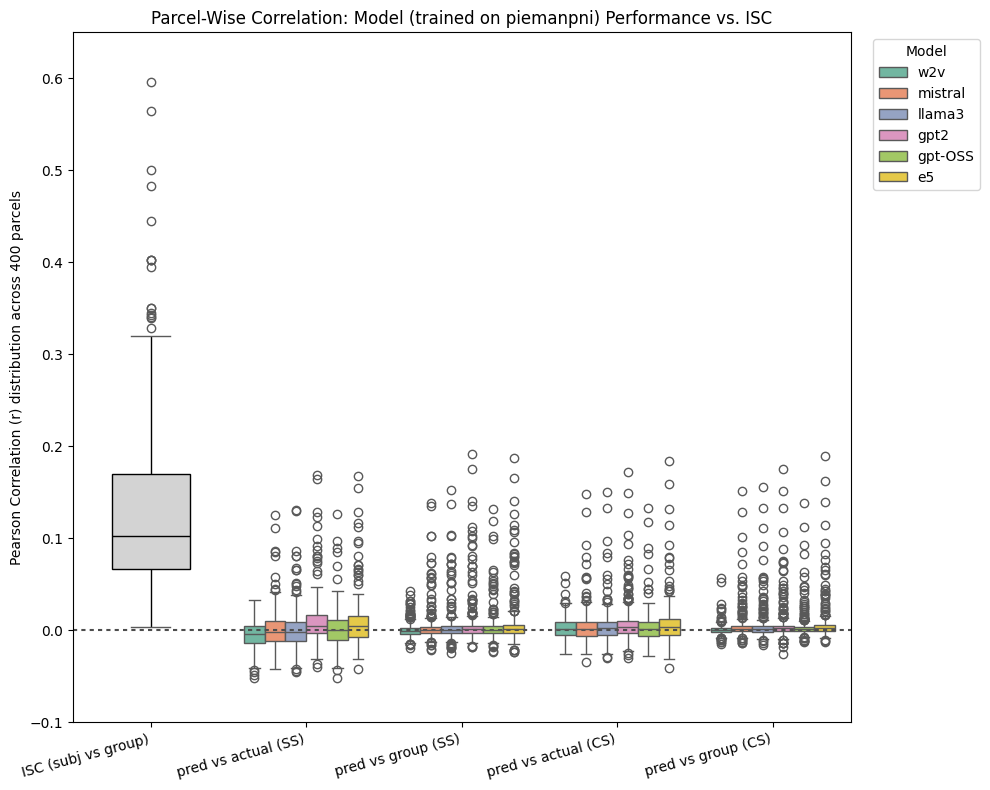

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# 設定
# =====================================================
model_list = ["w2v", "llama", "llama3", "gpt2", "gpt_oss", "gte"]
train_story = "piemanpni"
test_story  = "bronx"

base_dir = "/home/y-sato/venv/kenkyu1/analysis_corr"
out_path = f"{base_dir}/boxplot_corr_{train_story}_to_{test_story}_parcelMean.png"

corr_cols = [
    "pred_vs_group",
    "pred_vs_actual",
    "pred_vs_other_story",
    "pred_vs_other_story_group"
]

isc_col = "subj_vs_group"

# =====================================================
# データまとめ（★ 被験者 → パーセル平均）
# =====================================================
all_rows = []

# ===== ISC =====
df_isc = pd.read_csv(
    f"{base_dir}/{model_list[0]}_{train_story}_allsubjects_with_{test_story}_clean_corr_df.csv"
)

isc_rows = (
    df_isc
    .groupby("parcel")[isc_col]
    .mean()                         # ★ 被験者平均
    .reset_index(drop=True)
    .to_frame(name="correlation")
)

isc_rows["model"] = "ISC"
isc_rows["metric"] = "ISC"
all_rows.append(isc_rows)

# ===== 各モデル × 各指標 =====
for model_name in model_list:
    df = pd.read_csv(
        f"{base_dir}/{model_name}_{train_story}_allsubjects_with_{test_story}_clean_corr_df.csv"
    )

    for col in corr_cols:
        tmp = (
            df
            .groupby("parcel")[col]
            .mean()                 # ★ 被験者平均
            .reset_index(drop=True)
            .to_frame(name="correlation")
        )

        tmp["model"] = model_name
        tmp["metric"] = col
        all_rows.append(tmp)

plot_df = pd.concat(all_rows, ignore_index=True)

# =====================================================
# metric の順番
# =====================================================
metric_order = [
    "ISC",
    "pred_vs_actual",
    "pred_vs_group",
    "pred_vs_other_story",
    "pred_vs_other_story_group"
]

plot_df["metric"] = pd.Categorical(
    plot_df["metric"],
    categories=metric_order,
    ordered=True
)

# =====================================================
# 表示ラベル
# =====================================================
metric_label_map = {
    "ISC": "ISC (subj vs group)",
    "pred_vs_actual": "pred vs actual (SS)",
    "pred_vs_group": "pred vs group (SS)",
    "pred_vs_other_story": "pred vs actual (CS)",
    "pred_vs_other_story_group": "pred vs group (CS)"
}

model_label_map = {
    "ISC": "ISC",
    "w2v": "w2v",
    "llama": "mistral",
    "llama3": "llama3",
    "gpt2": "gpt2",
    "gpt_oss": "gpt-OSS",
    "gte": "e5"
}

plot_df["model_label"] = plot_df["model"].map(model_label_map)

# =====================================================
# ISC とそれ以外を分離
# =====================================================
df_isc = plot_df[plot_df["model"] == "ISC"]
df_model = plot_df[plot_df["model"] != "ISC"]

# =====================================================
# 描画
# =====================================================
plt.figure(figsize=(10, 8))
palette = sns.color_palette("Set2", n_colors=len(model_list) + 1)

# --- 通常モデル ---
ax = sns.boxplot(
    data=df_model,
    x="metric",
    y="correlation",
    hue="model_label",
    order=metric_order,
    dodge=True,
    palette=palette
)

# --- ISC（中央固定） ---
sns.boxplot(
    data=df_isc,
    x="metric",
    y="correlation",
    order=metric_order,
    width=0.5,
    showcaps=True,
    boxprops={"facecolor": "lightgray", "edgecolor": "black"},
    medianprops={"color": "black"},
    whiskerprops={"color": "black"},
    showfliers=True,
    ax=ax,
    hue="model_label",
    palette=palette
)

ax.axhline(0, color=".3", dashes=(2, 2))
ax.set_ylim(-0.1, 0.65)
ax.set_xlabel("")
ax.set_ylabel("Pearson Correlation (r) distribution across 400 parcels")
ax.set_title(
    f"Parcel-Wise Correlation: Model (trained on {train_story}) Performance vs. ISC"
)

ax.set_xticklabels(
    [metric_label_map[m] for m in metric_order],
    rotation=15,
    ha="right"
)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()


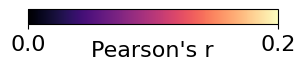

In [62]:
import matplotlib
fig = plt.figure(figsize=(5,5))
norm = matplotlib.colors.Normalize(-1, 1)
cb_ax = fig.add_axes([0.25, 0.25, 0.5, 0.03]) # start x, start y, length x, height y
cb = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='magma'), 
                  ticks=[-1, 1], cax=cb_ax, orientation='horizontal')
cb.set_label(f"Pearson's r", fontsize=16, labelpad=-10)
cb.ax.set_xticklabels(['0.0','0.2'], fontsize=16)
plt.savefig(f'../analysis_corr/correlation_bar.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

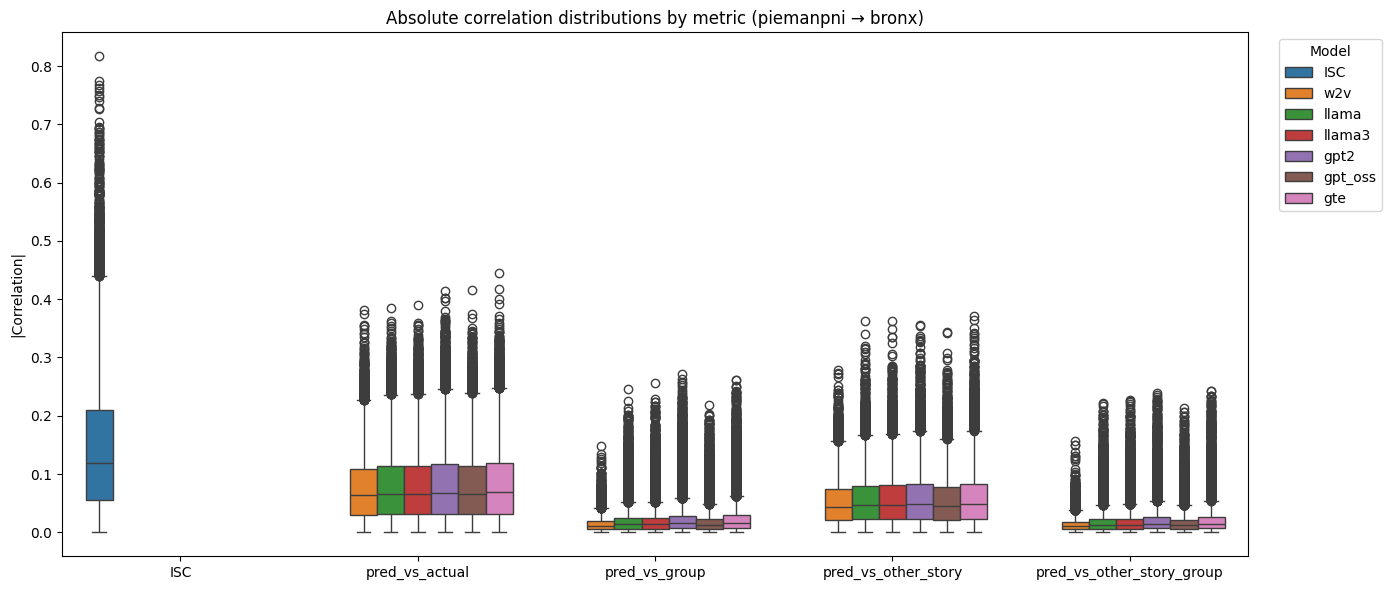

In [17]:

# ===== 絶対値列を追加 =====
plot_df["abs_correlation"] = plot_df["correlation"].abs()

plt.figure(figsize=(14, 6))

ax = sns.boxplot(
    data=plot_df,
    x="metric",
    y="abs_correlation",
    hue="model",
    order=metric_order,
    showfliers=True,
    dodge=True
)

ax.set_xlabel("")
ax.set_ylabel("|Correlation|")
ax.set_title(f"Absolute correlation distributions by metric ({train_story} → {test_story})")

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


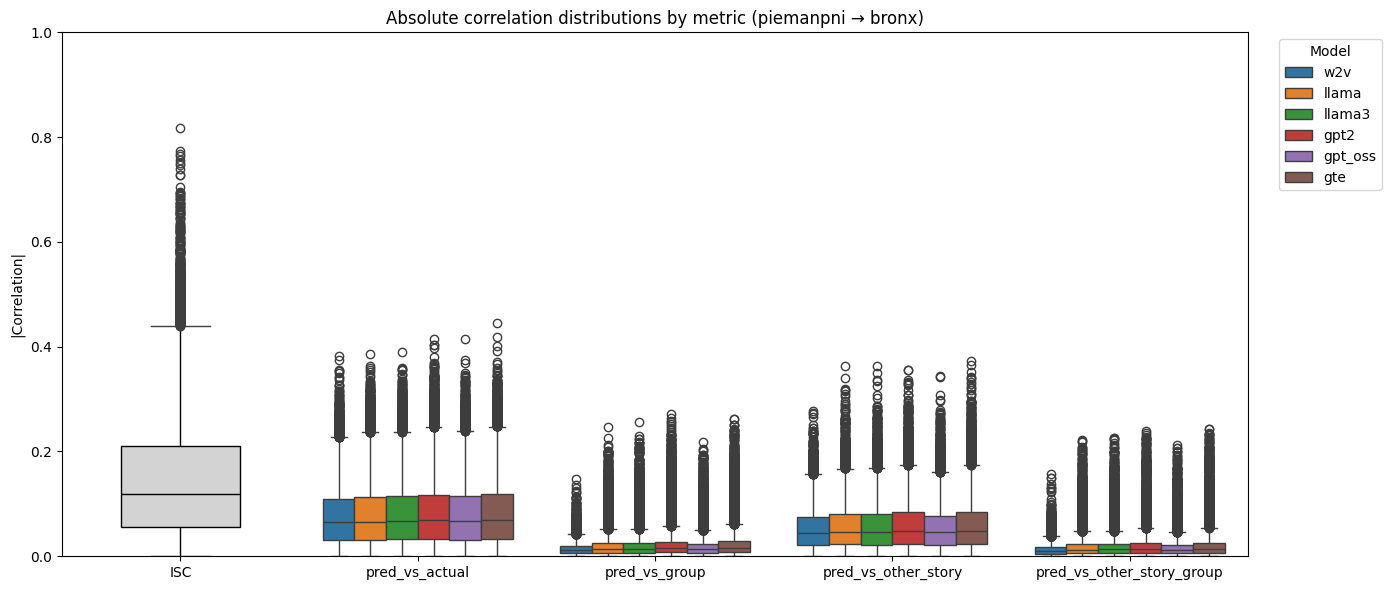

In [29]:
out_path = (
    f"{base_dir}/boxplot_corr_{train_story}_to_{test_story}_abs_hako.png"
)
# ===== 絶対値列 =====
plot_df["abs_correlation"] = plot_df["correlation"].abs()

# ===== ISC とそれ以外を分ける =====
df_isc = plot_df[plot_df["model"] == "ISC"]
df_model = plot_df[plot_df["model"] != "ISC"]

plt.figure(figsize=(14, 6))

# --- 通常モデル（色付き・dodgeあり） ---
ax = sns.boxplot(
    data=df_model,
    x="metric",
    y="abs_correlation",
    hue="model",
    order=metric_order,
    showfliers=True,
    dodge=True
)

# --- ISC（中央・単色） ---
sns.boxplot(
    data=df_isc,
    x="metric",
    y="abs_correlation",
    order=metric_order,
    width=0.5,
    showcaps=True,
    boxprops={"facecolor": "lightgray", "edgecolor": "black"},
    medianprops={"color": "black"},
    whiskerprops={"color": "black"},
    showfliers=True,
    ax=ax
)
ax.set_ylim(0, 1.0)
ax.set_xlabel("")
ax.set_ylabel("|Correlation|")
ax.set_title(f"Absolute correlation distributions by metric ({train_story} → {test_story})")

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()


In [18]:
# =====================================================
# ★ 追加：全モデル比較ヒストグラム（PNG保存 + 凡例改善）
# =====================================================

import matplotlib.pyplot as plt
import numpy as np

# 比較する4つのメトリクス
plot_metrics = [
    "pred_vs_actual",
    "pred_vs_other_story",
    "pred_vs_group",
    "pred_vs_other_story_group"
]

colors = {
    "pred_vs_actual": "tab:blue",
    "pred_vs_other_story": "tab:orange",
    "pred_vs_group": "tab:green",
    "pred_vs_other_story_group": "tab:red",
}

# ================================
# ★ モデル名置き換え
# ================================
rename_map = {
    "llama": "mistral",
    "gte": "e5",
}
df_summary["model_plot"] = df_summary["model"].replace(rename_map)
df_summary[plot_metrics] = np.sqrt(np.abs(df_summary[plot_metrics]))
plt.figure(figsize=(12, 6))

models = df_summary["model_plot"].tolist()
x = np.arange(len(models))
bar_width = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]

# 棒グラフの描画
for metric, offset in zip(plot_metrics, offsets):
    plt.bar(
        x + offset * bar_width,
        df_summary[metric],
        width=bar_width,
        color=colors[metric],
        label=metric
    )

plt.xticks(x, models, rotation=45)
plt.ylabel("Mean squared correlation")
plt.title("Mean squared correlations across models")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()

# ★ PNG 保存
save_path = f"../analysis_corr/{train_story}_model_comparison_abs_bars_alpha.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"Saved: {save_path}")


Saved: ../analysis_corr/bronx_model_comparison_abs_bars_alpha.png



Processing model: w2v


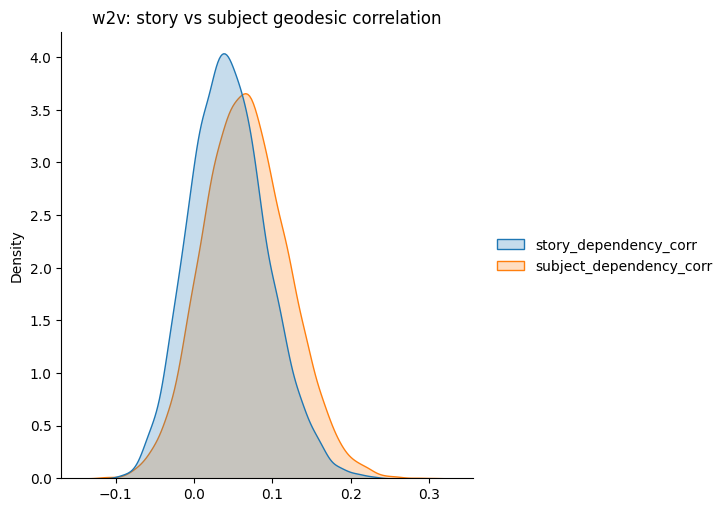

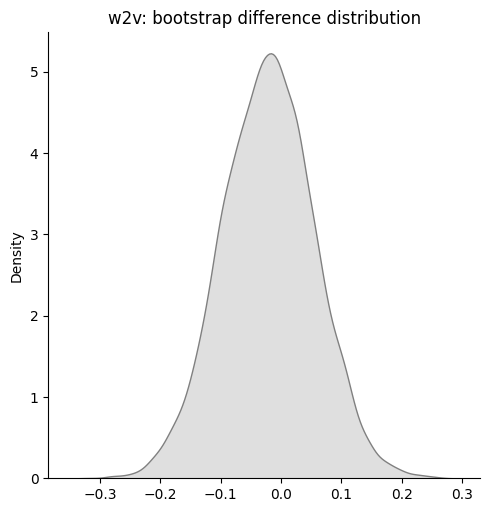


Processing model: llama


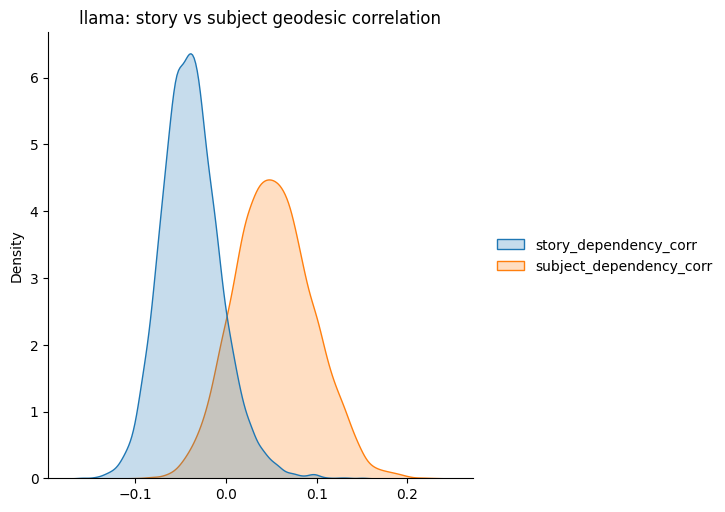

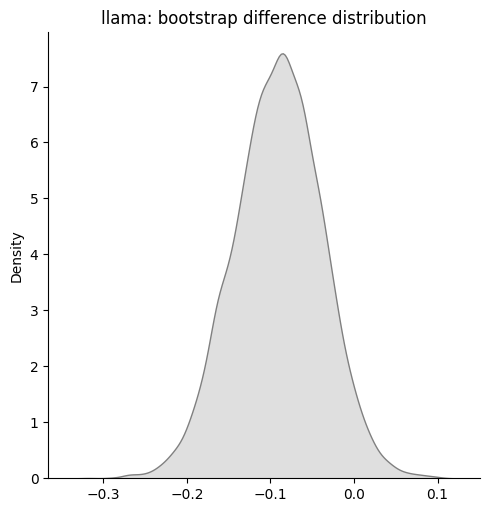


Processing model: llama3


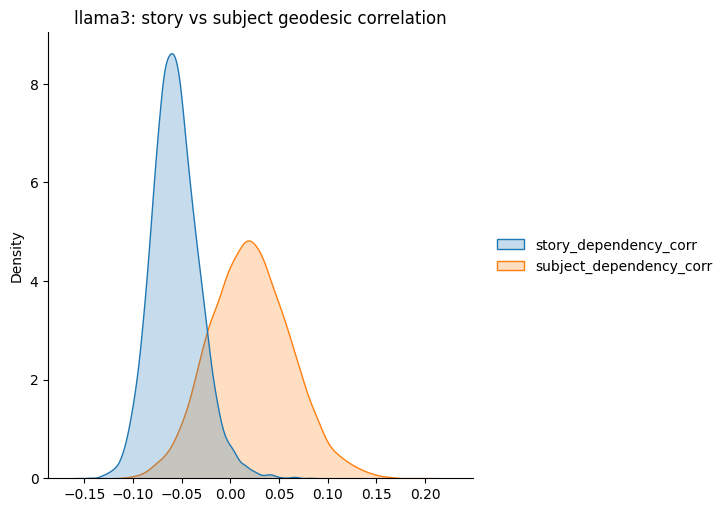

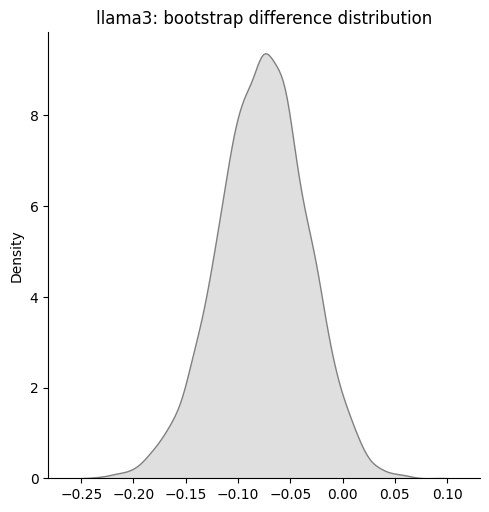


Processing model: gpt2


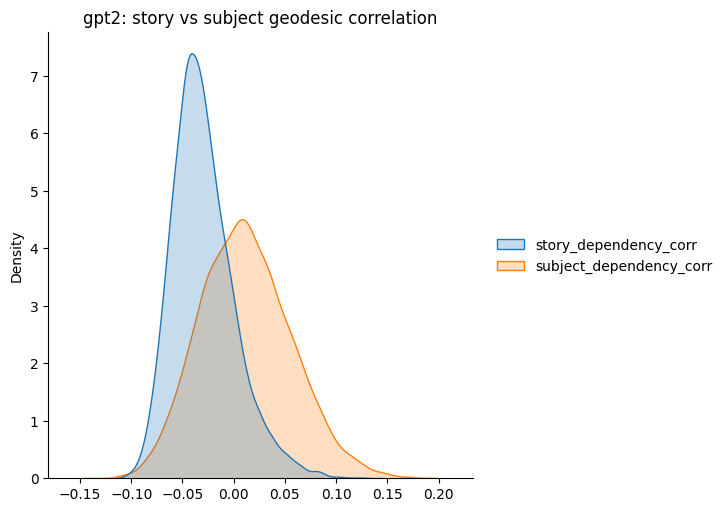

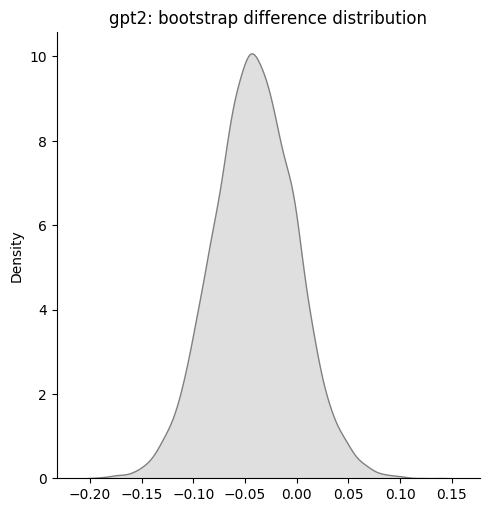


Processing model: gpt_oss


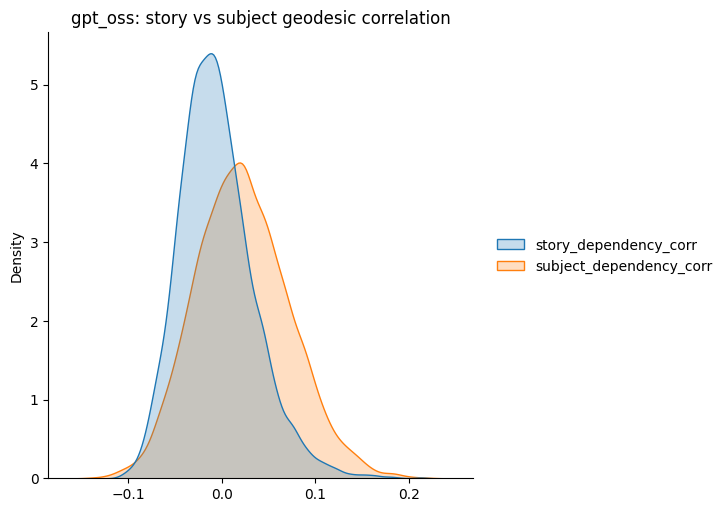

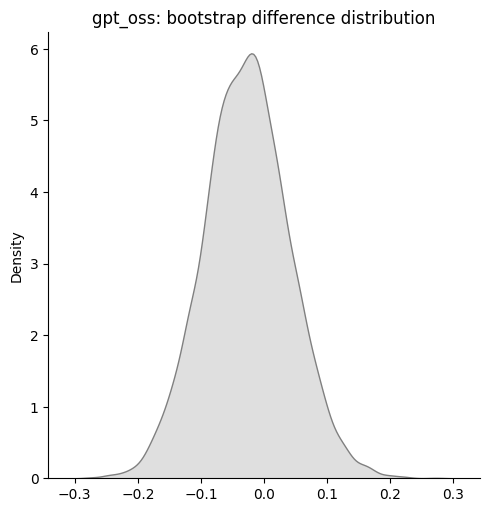


Processing model: gte


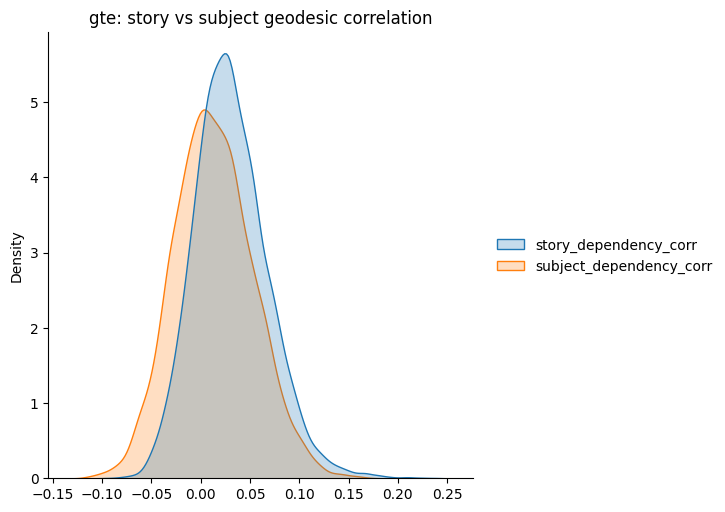

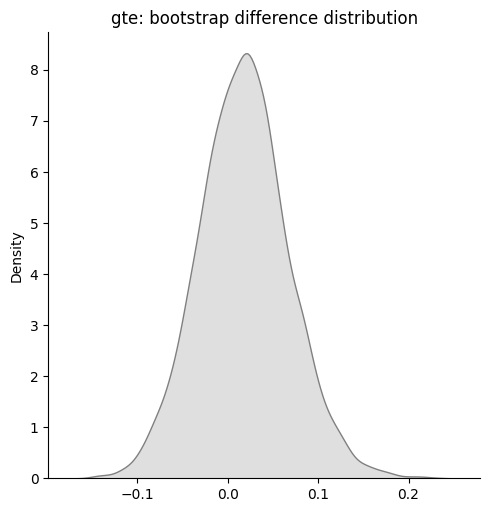


Saved giant figure: ../analysis_corr/bronx_all_models_bootstrap_kde_grid.png

===== Summary Result =====
     model  boot_mean_diff  pvalue    ci_low   ci_high
0      w2v       -0.021676  0.3873 -0.171882  0.126613
1    llama       -0.091279  0.0381 -0.195488  0.009564
2   llama3       -0.077031  0.0328 -0.164676  0.004573
3     gpt2       -0.041273  0.1456 -0.120092  0.037949
4  gpt_oss       -0.027538  0.3329 -0.159593  0.107661
5      gte        0.017755  0.6393 -0.078767  0.119829

Saved: train_story_bootstrap_summary_results.csv


In [19]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# 一括処理したいモデル一覧
# =====================================================
model_list = ["w2v", "llama", "llama3", "gpt2", "gpt_oss", "gte"]
train_story = "bronx"
test_story = "piemanpni"

base_dir = "/home/y-sato/venv/kenkyu1/analysis_corr"

# =====================================================
# 結果をまとめるテーブル
# =====================================================
summary_rows = []

# =====================================================
# ブートストラップ設定
# =====================================================
nregions = 400
nboot = 10000
alpha = 0.05

# =====================================================
# モデルごとにループ処理
# =====================================================
for model_name in model_list:
    print("\n==========================================")
    print(f"Processing model: {model_name}")
    print("==========================================")

    input_file = f"{base_dir}/{model_name}_{train_story}_allsubjects_with_{test_story}_clean_corr_df.csv"
    #input_file = f"{base_dir}/{model_name}_{train_story}_allsubjects_with_{test_story}_corr_df.csv"
    # ----------------------
    # 1. データ読み込み
    # ----------------------
    df = pd.read_csv(input_file)

    # ----------------------
    # 2. 使う列を読み出し
    # ----------------------
    # a = pred_vs_actual
    # b = pred_vs_group
    # c = pred_vs_other_story

    a = df["pred_vs_actual"].values.copy()
    b = df["pred_vs_group"].values.copy()
    c = df["pred_vs_other_story"].values.copy()

    # NaN をゼロに置換
    a[np.isnan(a)] = 0
    b[np.isnan(b)] = 0
    c[np.isnan(c)] = 0

    a = a ** 2
    b = b ** 2
    c = c ** 2
    
    # ----------------------
    # 3. ブートストラップ
    # ----------------------
    bootcorr1 = np.zeros(nboot)
    bootcorr2 = np.zeros(nboot)

    for B in range(nboot):
        bootsample = np.random.randint(0, high=nregions, size=nregions)
        bootcorr1[B], _ = pearsonr(a[bootsample], b[bootsample])
        bootcorr2[B], _ = pearsonr(a[bootsample], c[bootsample])

    # ----------------------
    # 4. 差の分布と p 値
    # ----------------------
    bootdiff = bootcorr1 - bootcorr2
    pvalue = 1 - (np.sum(bootdiff < 0) / nboot)

    # 95% CI
    bootdiff_sorted = np.sort(bootdiff)
    ci_low = bootdiff_sorted[int(np.floor((alpha/2) * nboot))]
    ci_high = bootdiff_sorted[int(np.floor((1 - alpha/2) * nboot))]

    # ----------------------
    # 5. 結果をまとめる
    # ----------------------
    summary_rows.append({
        "model": model_name,
        "boot_mean_diff": bootdiff.mean(),
        "pvalue": pvalue,
        "ci_low": ci_low,
        "ci_high": ci_high
    })

    # ----------------------
    # 6. KDE プロット（必要なら保存も可能）
    # ----------------------
    boot_df = pd.DataFrame({
        "story_dependency_corr": bootcorr1,
        "subject_dependency_corr": bootcorr2
    })

    sns.displot(boot_df, kind="kde", fill=True)
    plt.title(f"{model_name}: story vs subject geodesic correlation")
    plt.show()

    sns.displot(bootdiff, kind="kde", fill=True, color="grey")
    plt.title(f"{model_name}: bootstrap difference distribution")
    plt.show()

# =====================================================
# ★ すべてのモデルの KDE を 1 枚にまとめて保存
# =====================================================

fig, axes = plt.subplots(len(model_list), 2, figsize=(12, 5 * len(model_list)))

for i, result in enumerate(summary_rows):
    model_name = result["model"]

    # 再読み込み（plot用）
    #input_file = f"{base_dir}/{model_name}_{train_story}_allsubjects_with_{test_story}_corr_df.csv"
    input_file = f"{base_dir}/{model_name}_{train_story}_allsubjects_with_{test_story}_corr_df.csv"
    df = pd.read_csv(input_file)

    a = df["pred_vs_actual"].values.copy()
    b = df["pred_vs_group"].values.copy()
    c = df["pred_vs_other_story"].values.copy()

    a[np.isnan(a)] = 0
    b[np.isnan(b)] = 0
    c[np.isnan(c)] = 0

    a = a ** 2
    b = b ** 2
    c = c ** 2

    # ---- bootstrap 再計算（プロット用）----
    bootcorr1 = np.zeros(nboot)
    bootcorr2 = np.zeros(nboot)
    for B in range(nboot):
        bootsample = np.random.randint(0, high=nregions, size=nregions)
        bootcorr1[B], _ = pearsonr(a[bootsample], b[bootsample])
        bootcorr2[B], _ = pearsonr(a[bootsample], c[bootsample])

    bootdiff = bootcorr1 - bootcorr2

    # =====================================================
    # 左側：bootcorr1 & bootcorr2
    # =====================================================
    ax1 = axes[i, 0]
    sns.kdeplot(bootcorr1, ax=ax1, fill=True, alpha=0.6, label="story_dependency_corr")
    sns.kdeplot(bootcorr2, ax=ax1, fill=True, alpha=0.6, label="subject_dependency_corr")
    ax1.set_title(f"{model_name}: story/subject KDE")
    ax1.legend()

    # =====================================================
    # 右側：bootdiff
    # =====================================================
    ax2 = axes[i, 1]
    sns.kdeplot(bootdiff, ax=ax2, fill=True, color="grey", alpha=0.7)
    ax2.set_title(f"{model_name}: diff distribution")


plt.tight_layout()
save_path = f"../analysis_corr/{train_story}_all_models_bootstrap_kde_grid.png"
plt.savefig(save_path, dpi=300)
plt.close()

print(f"\nSaved giant figure: {save_path}")

# =====================================================
# ★ すべての結果を DataFrame に
# =====================================================
summary_df = pd.DataFrame(summary_rows)
print("\n===== Summary Result =====")
print(summary_df)

# CSV 保存
summary_df.to_csv(f"../analysis_corr/bootstrap/{train_story}_bootstrap_summary_clean_results_a.csv", index=False)
print("\nSaved: train_story_bootstrap_summary_results.csv")



Processing model: w2v


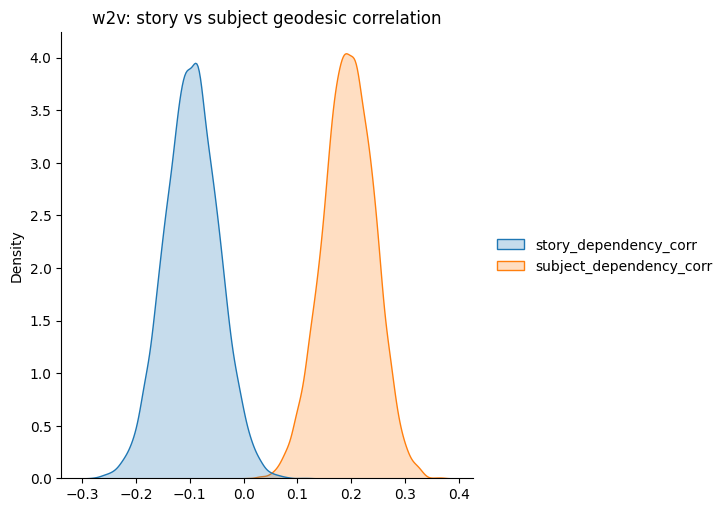

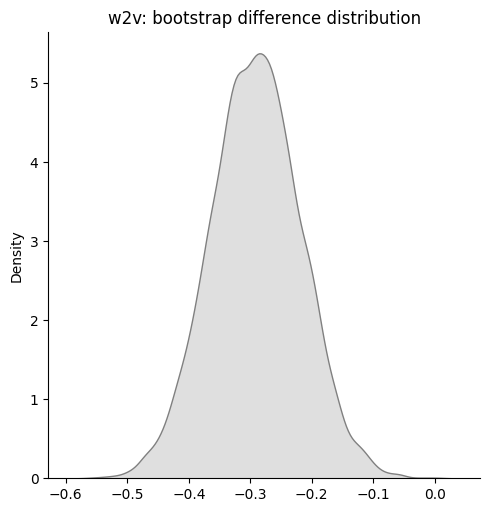


Processing model: llama


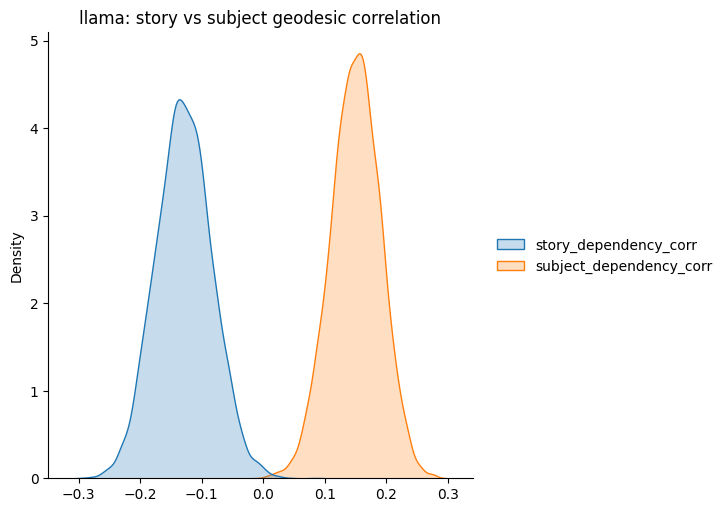

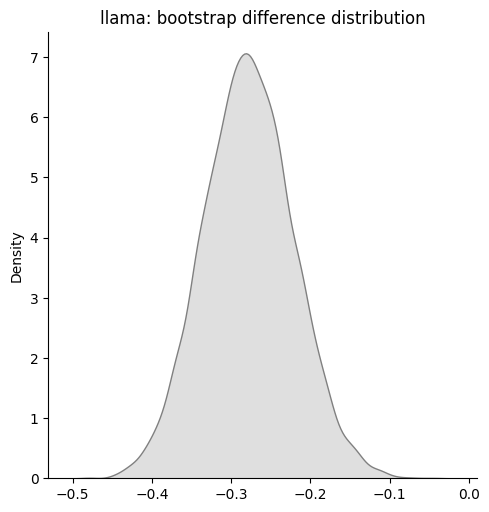


Processing model: llama3


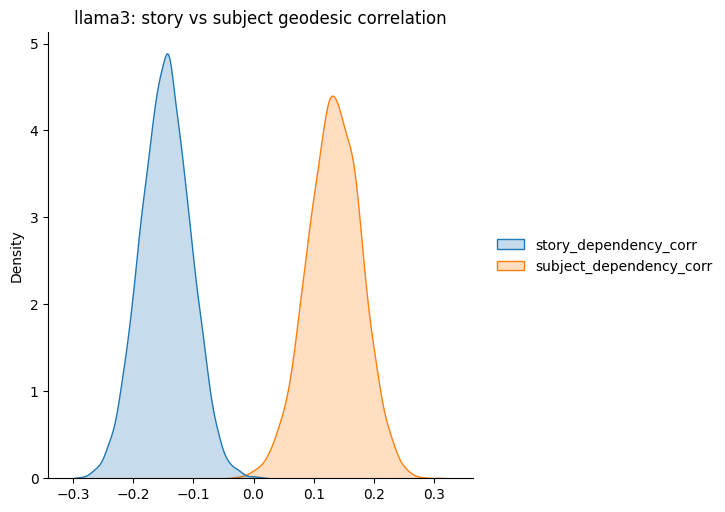

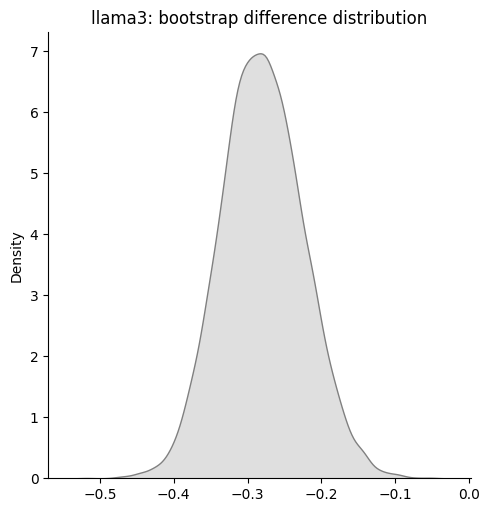


Processing model: gpt2


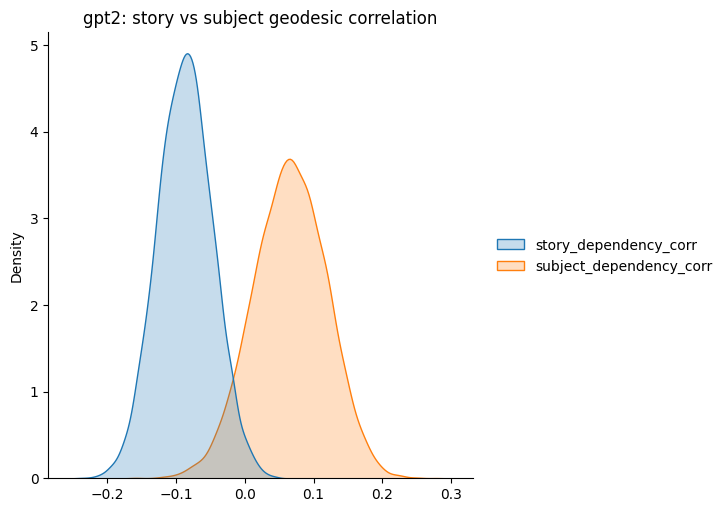

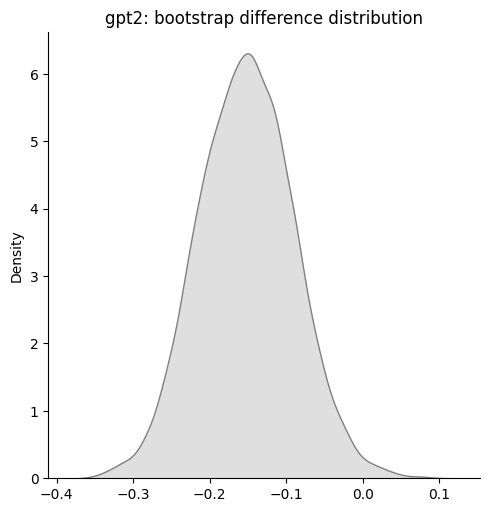


Processing model: gpt_oss


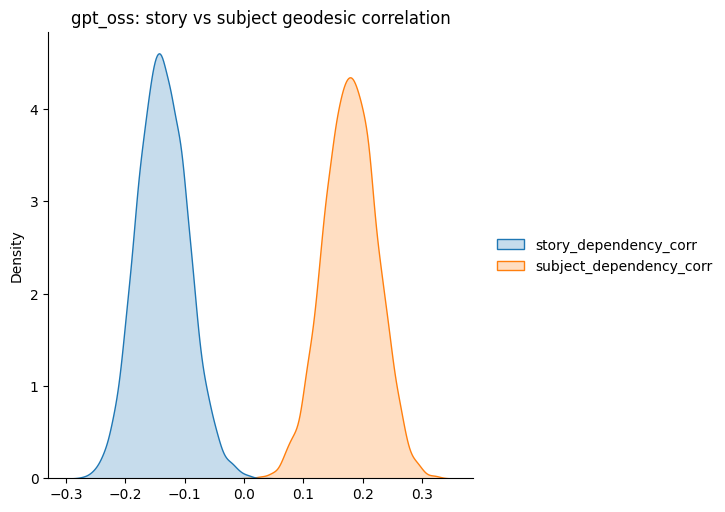

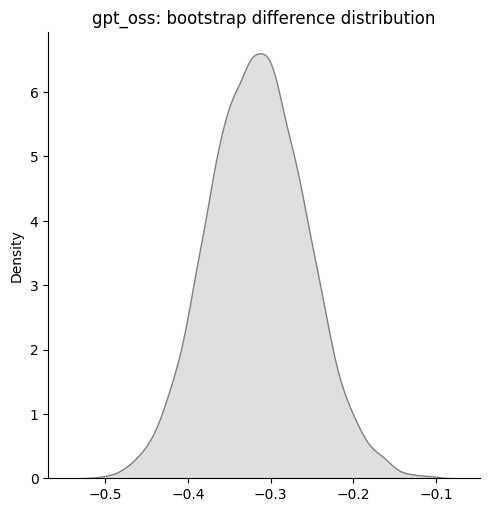


Processing model: gte


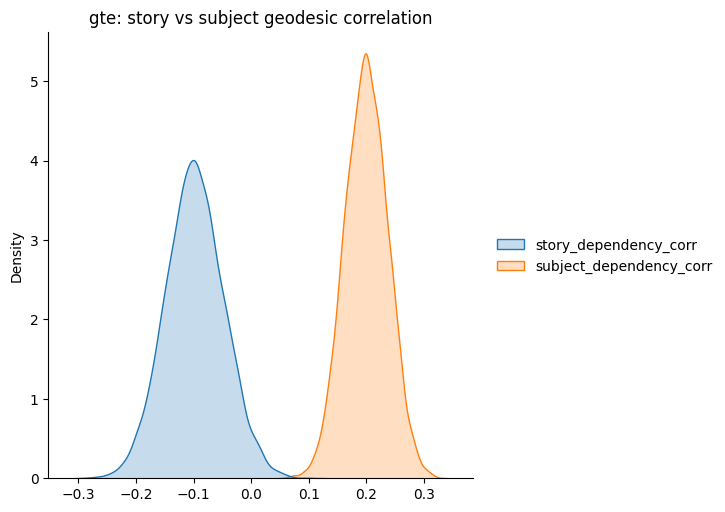

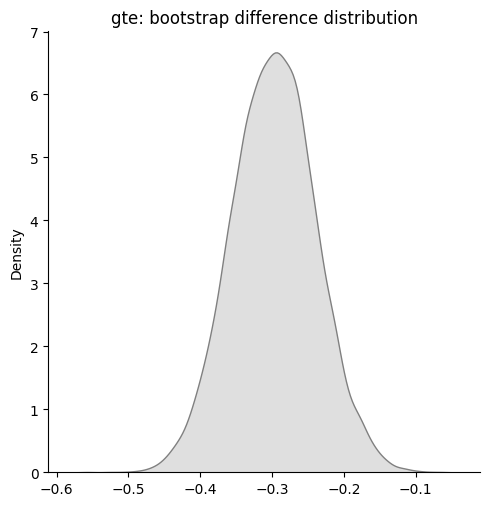


Saved giant figure: ../analysis_corr/bronx_all_models_bootstrap_kde_grid.png

===== Summary Result =====
     model  boot_mean_diff  pvalue    ci_low   ci_high
0      w2v       -0.291334  0.0001 -0.432843 -0.149878
1    llama       -0.278544  0.0000 -0.387912 -0.166782
2   llama3       -0.280038  0.0000 -0.384481 -0.169454
3     gpt2       -0.152426  0.0089 -0.271290 -0.028926
4  gpt_oss       -0.316015  0.0000 -0.428937 -0.197649
5      gte       -0.297766  0.0000 -0.410656 -0.181691

Saved: train_story_bootstrap_summary_results.csv


In [22]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# 一括処理したいモデル一覧
# =====================================================
model_list = ["w2v", "llama", "llama3", "gpt2", "gpt_oss", "gte"]
train_story = "bronx"
test_story = "piemanpni"

base_dir = "/home/y-sato/venv/kenkyu1/analysis_corr"

# =====================================================
# 結果をまとめるテーブル
# =====================================================
summary_rows = []
subject_A = "sub-281"
subject_B = "sub-315"
# =====================================================
# ブートストラップ設定
# =====================================================
nregions = 400
nboot = 10000
alpha = 0.05

# =====================================================
# モデルごとにループ処理
# =====================================================
for model_name in model_list:
    print("\n==========================================")
    print(f"Processing model: {model_name}")
    print("==========================================")

    input_file = f"{base_dir}/{model_name}_{train_story}_allsubjects_with_{test_story}_corr_df.csv"
    #input_file = f"{base_dir}/{model_name}_{train_story}_allsubjects_with_{test_story}_corr_df.csv"
    # ----------------------
    # 1. データ読み込み
    # ----------------------
    df = pd.read_csv(input_file)

    # ----------------------
    # 2. 使う列を読み出し
    # ----------------------
    # a = pred_vs_actual
    # b = pred_vs_group
    # c = pred_vs_other_story
    df_bold = pd.read_csv(f"../parcels_csv/{train_story}_parcels_all_subjects.csv")

    # 被験者 A の BOLD（nTR × 400）
    bold_A = df_bold[df_bold["sub"] == subject_A]
    Y_A = bold_A[[f"parcel_{i}" for i in range(400)]].values
    
    # =====================================================
    # モデルごとの予測 CSV 読み込み
    # =====================================================
    pred_dir = "../predicted_all_csv/"
    pred_file = f"{pred_dir}/{model_name}_bronx_predicted.csv"
    df_pred = pd.read_csv(pred_file)
    
    # 被験者 A の predicted
    pred_A = df_pred[df_pred["subject"] == subject_A]
    pred_A = pred_A[[f"parcel_{i}" for i in range(400)]].values
    
    # 被験者 B の predicted
    pred_B = df_pred[df_pred["subject"] == subject_B]
    pred_B = pred_B[[f"parcel_{i}" for i in range(400)]].values

    a = Y_A.mean(axis=0)
    b = pred_B.mean(axis=0)
    c = pred_A.mean(axis=0)
    # a = df["pred_vs_actual"].values.copy()
    # b = df["pred_vs_group"].values.copy()
    # c = df["pred_vs_other_story"].values.copy()

    # NaN をゼロに置換
    a[np.isnan(a)] = 0
    b[np.isnan(b)] = 0
    c[np.isnan(c)] = 0

    # a = a ** 2
    # b = b ** 2
    # c = c ** 2
    
    # ----------------------
    # 3. ブートストラップ
    # ----------------------
    bootcorr1 = np.zeros(nboot)
    bootcorr2 = np.zeros(nboot)

    for B in range(nboot):
        bootsample = np.random.randint(0, high=nregions, size=nregions)
        bootcorr1[B], _ = pearsonr(a[bootsample], b[bootsample])
        bootcorr2[B], _ = pearsonr(a[bootsample], c[bootsample])

    # ----------------------
    # 4. 差の分布と p 値
    # ----------------------
    bootdiff = bootcorr1 - bootcorr2
    pvalue = 1 - (np.sum(bootdiff < 0) / nboot)

    # 95% CI
    bootdiff_sorted = np.sort(bootdiff)
    ci_low = bootdiff_sorted[int(np.floor((alpha/2) * nboot))]
    ci_high = bootdiff_sorted[int(np.floor((1 - alpha/2) * nboot))]

    # ----------------------
    # 5. 結果をまとめる
    # ----------------------
    summary_rows.append({
        "model": model_name,
        "boot_mean_diff": bootdiff.mean(),
        "pvalue": pvalue,
        "ci_low": ci_low,
        "ci_high": ci_high
    })

    # ----------------------
    # 6. KDE プロット（必要なら保存も可能）
    # ----------------------
    boot_df = pd.DataFrame({
        "story_dependency_corr": bootcorr1,
        "subject_dependency_corr": bootcorr2
    })

    sns.displot(boot_df, kind="kde", fill=True)
    plt.title(f"{model_name}: story vs subject geodesic correlation")
    plt.show()

    sns.displot(bootdiff, kind="kde", fill=True, color="grey")
    plt.title(f"{model_name}: bootstrap difference distribution")
    plt.show()

# =====================================================
# ★ すべてのモデルの KDE を 1 枚にまとめて保存
# =====================================================

fig, axes = plt.subplots(len(model_list), 2, figsize=(12, 5 * len(model_list)))

for i, result in enumerate(summary_rows):
    model_name = result["model"]

    # 再読み込み（plot用）
    #input_file = f"{base_dir}/{model_name}_{train_story}_allsubjects_with_{test_story}_corr_df.csv"
    input_file = f"{base_dir}/{model_name}_{train_story}_allsubjects_with_{test_story}_corr_df.csv"
    df = pd.read_csv(input_file)
    df_bold = pd.read_csv(f"../parcels_csv/{train_story}_parcels_all_subjects_normalized.csv")

    # 被験者 A の BOLD（nTR × 400）
    bold_A = df_bold[df_bold["sub"] == subject_A]
    Y_A = bold_A[[f"parcel_{i}" for i in range(400)]].values
    
    # =====================================================
    # モデルごとの予測 CSV 読み込み
    # =====================================================
    pred_dir = "../predicted_all_csv/"
    pred_file = f"{pred_dir}/{model_name}_bronx_predicted_scaled.csv"
    df_pred = pd.read_csv(pred_file)
    
    # 被験者 A の predicted
    pred_A = df_pred[df_pred["subject"] == subject_A]
    pred_A = pred_A[[f"parcel_{i}" for i in range(400)]].values
    
    # 被験者 B の predicted
    pred_B = df_pred[df_pred["subject"] == subject_B]
    pred_B = pred_B[[f"parcel_{i}" for i in range(400)]].values

    a = Y_A.mean(axis=0)
    b = pred_B.mean(axis=0)
    c = pred_A.mean(axis=0)

    # a = df["pred_vs_actual"].values.copy()
    # b = df["pred_vs_group"].values.copy()
    # c = df["pred_vs_other_story"].values.copy()

    a[np.isnan(a)] = 0
    b[np.isnan(b)] = 0
    c[np.isnan(c)] = 0

    # a = a ** 2
    # b = b ** 2
    # c = c ** 2

    # ---- bootstrap 再計算（プロット用）----
    bootcorr1 = np.zeros(nboot)
    bootcorr2 = np.zeros(nboot)
    for B in range(nboot):
        bootsample = np.random.randint(0, high=nregions, size=nregions)
        bootcorr1[B], _ = pearsonr(a[bootsample], b[bootsample])
        bootcorr2[B], _ = pearsonr(a[bootsample], c[bootsample])

    bootdiff = bootcorr1 - bootcorr2

    # =====================================================
    # 左側：bootcorr1 & bootcorr2
    # =====================================================
    ax1 = axes[i, 0]
    sns.kdeplot(bootcorr1, ax=ax1, fill=True, alpha=0.6, label="story_dependency_corr")
    sns.kdeplot(bootcorr2, ax=ax1, fill=True, alpha=0.6, label="subject_dependency_corr")
    ax1.set_title(f"{model_name}: story/subject KDE")
    ax1.legend()

    # =====================================================
    # 右側：bootdiff
    # =====================================================
    ax2 = axes[i, 1]
    sns.kdeplot(bootdiff, ax=ax2, fill=True, color="grey", alpha=0.7)
    ax2.set_title(f"{model_name}: diff distribution")


plt.tight_layout()
save_path = f"../analysis_corr/{train_story}_all_models_bootstrap_kde_grid.png"
plt.savefig(save_path, dpi=300)
plt.close()

print(f"\nSaved giant figure: {save_path}")

# =====================================================
# ★ すべての結果を DataFrame に
# =====================================================
summary_df = pd.DataFrame(summary_rows)
print("\n===== Summary Result =====")
print(summary_df)

# CSV 保存
summary_df.to_csv(f"../analysis_corr/bootstrap/bootstrap_check_summary_results.csv", index=False)
print("\nSaved: train_story_bootstrap_summary_results.csv")
